# RO change over time

## Imports

In [ ]:
import datetime
import matplotlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import seaborn as sns
import xarray as xr
import tqdm
import pathlib
import cmocean
import os
import src.XRO
import copy
import scipy.stats
import warnings
import calendar

# import gsw

## set plotting specs
sns.set(rc={"axes.facecolor": "white", "axes.grid": False}, palette="colorblind")

## bump up DPI
mpl.rcParams["figure.dpi"] = 100

## get filepaths
DATA_FP = pathlib.Path(os.environ["DATA_FP"])
SAVE_FP = pathlib.Path(os.environ["SAVE_FP"])

## specify args

In [ ]:
## should we remove median?
REMOVE_MEDIAN = True

## Functions

In [ ]:
def get_rolling_std(data, n=20):
    """
    Get standard deviation, computing over time and ensemble member. To increase
    sample size for variance estimate, compute over time window of 2n+1
    years, centered at given year.
    """

    ## do the computation
    kwargs = dict(fn=np.std, n=n, reduce_ensemble_dim=False)
    data_std = src.utils.get_rolling_fn_bymonth(data, **kwargs)

    ## unstack year and month
    data_std = src.utils.unstack_month_and_year(data_std)

    return data_std


def get_fits_over_time(data_rolling, model, by_member=False, **fit_kwargs):
    """Get RO fits for each ensemble member as a function of time."""

    ## empty list to hold results
    fits = []

    ## loop through years
    for y in tqdm.tqdm(data_rolling.year):

        ## get data for year
        data_y = data_rolling.sel(year=y)

        if by_member:

            ## separate fit for each ensemble member
            fits_ = []
            for m in data_rolling.member:
                with warnings.catch_warnings(action="ignore"):
                    fits_.append(model.fit_matrix(data_y.sel(member=m), **fit_kwargs))
            fit = xr.concat(fits_, dim=data_y.member)

        else:

            ## fit for all ensemble members together
            with warnings.catch_warnings(action="ignore"):
                fit = model.fit_matrix(data_y, **fit_kwargs)

        ## track fits
        # fits.append(fit.drop_vars(["time", "X", "Y", "Yfit"]))
        fits.append(fit)

    ## put back in xarray
    fits = xr.concat(fits, dim=data_rolling.year)

    return fits


def get_fits_over_time_wrapper(
    data_rolling, model, by_member=False, fname=None, **fit_kwargs
):
    """wrapper function to handle saving/loading"""

    ## function to compute fits
    get_fits = lambda: get_fits_over_time(
        data_rolling, model=model, by_member=by_member, **fit_kwargs
    )

    ## if fname not specified, compute without loading/saving
    if fname is None:
        fits = get_fits()

    else:

        ## full path to file
        fp = pathlib.Path(os.environ["SAVE_FP"], "fits_cesm", fname)

        ## load if it already exists
        if fp.is_file():
            fits = xr.open_dataset(fp)

        ## otherwise, compute and save
        else:
            fits = get_fits()
            fits.to_netcdf(fp)

    return fits


def get_sims_over_time(model, params, **simulation_kwargs):
    """Compute stats over time"""

    ## take ensemble mean if necessary
    if "member" in params.dims:
        params = params.mean("member")

    ## empty list to hold result
    sims = []

    ## loop through years
    for y in tqdm.tqdm(params.year):

        ## do simulation
        sim_y = model.simulate(fit_ds=params.sel(year=y), **simulation_kwargs)

        ## append
        sims.append(sim_y)

    ## put back in xarray
    sims = xr.concat(sims, dim=params.year)

    return sims


def save(fig, fname, dpi=800, do_save=False):
    """save figure to file"""

    ## get save directory
    save_dir = pathlib.Path(os.environ["SAVE_FP"], "pre-egu-updates")

    ## get fname
    fname = f"{fname}-{varnames[0]}-subtract_median_{REMOVE_MEDIAN}.pdf"

    if do_save:
        fig.savefig(save_dir / fname, dpi=dpi, format="pdf")

    return


def get_perturbed_NRO(params, nro_form_idx=None, nro_type="NROT_Lac"):
    """
    Fix values of R parameter set.
    if 'fix_others' is True, then other parameters are fixed to their
    initial value. Otherwise, given parameter is fixed to its initial value
    """

    ## initialize empty array to hold parameters
    params_new = copy.deepcopy(params)
    params_new[nro_type] = params_new[nro_type].transpose("year", "nro_form", ...)

    ## get numpy version of linear operator
    NRO_Lac = params_new[nro_type].values

    ## update parameter
    if nro_form_idx is None:
        NRO_Lac = NRO_Lac[:1]

    else:
        NRO_Lac[:, nro_form_idx] = NRO_Lac[:1, nro_form_idx]

    ## add back to parameters
    params_new[nro_type] = xr.ones_like(params_new[nro_type]) * NRO_Lac

    return params_new


def get_ddt(data):
    """differentiate with respect to time"""
    data_ = copy.deepcopy(data)
    data_ = data_.assign_coords({"t_idx": ("time", np.arange(len(data_.time)))})
    data_ = data_.swap_dims({"time": "t_idx"})

    ## differentiate
    ddt_data = data_.differentiate("t_idx").swap_dims({"t_idx": "time"})

    ## mult. by 12 to convert from 1/mo to 1/yr
    return 12 * ddt_data

## Load data

### T, h

In [ ]:
## open data
Th = src.utils.load_cesm_indices(load_z20=True, load_h_cust=True, max_grad=True)
Th = Th.fillna(0)

#### Load ELI

In [ ]:
## Load ELI
eli_all = xr.open_dataset(pathlib.Path(DATA_FP, "cesm/eli.nc"))
eli_forced, eli = src.utils.separate_forced(eli_all)

## add to data
Th = xr.merge([Th, eli])

Scale it

#### Merged Niño index

In [ ]:
## function to get merged nino3/34 regions
def get_nino_merged(x):
    idx = dict(latitude=slice(-5, 5), longitude=slice(190, 270))
    return x.sel(idx).mean(["longitude", "latitude"])


def get_Te(x):
    idx = dict(latitude=slice(-5, 5), longitude=slice(230, 280))
    return x.sel(idx).mean(["longitude", "latitude"])


def get_Tw(x):
    idx = dict(latitude=slice(-5, 5), longitude=slice(180, 230))
    return x.sel(idx).mean(["longitude", "latitude"])


## spatial data
forced, anom = src.utils.load_consolidated()

## compute
Th["T_m"] = src.utils.reconstruct_wrapper(anom[["sst", "sst_comp"]], get_nino_merged)[
    "sst"
]
Th["T_e"] = src.utils.reconstruct_wrapper(anom[["sst", "sst_comp"]], get_Te)["sst"]
Th["T_w"] = src.utils.reconstruct_wrapper(anom[["sst", "sst_comp"]], get_Tw)["sst"]

#### OHC

In [ ]:
def load_consolidated_wide():
    """utility function to load consolidated data"""

    ## directory with data
    CONS_DIR = pathlib.Path(os.environ["DATA_FP"], "cesm", "consolidated_05")

    ## function to align and open
    kwargs = dict(pop_vars=["u", "u_comp", "T", "T_comp", "w", "w_comp"])
    align_and_open = lambda fp: src.utils.align_pop_times(xr.open_dataset(fp), **kwargs)

    ## open data and align pop times
    kwargs = dict(pop_vars=["u", "u_comp", "T", "T_comp", "w", "w_comp"])
    forced = align_and_open(CONS_DIR / "forced.nc")
    anom = align_and_open(CONS_DIR / "anom.nc")

    return forced, anom


forced_wide, anom_wide = load_consolidated_wide()

In [ ]:
lon_avg = lambda x, lons: x.sel(longitude=slice(*lons)).mean("longitude")

## compute ohc
Th["h_w_ohc"] = src.utils.reconstruct_wrapper(
    anom_wide[["T", "T_comp"]],
    lambda x: lon_avg(x.integrate("z_t"), (120, 180)),
)["T"]

## compute ohc
Th["h_ohc"] = src.utils.reconstruct_wrapper(
    anom_wide[["T", "T_comp"]],
    lambda x: lon_avg(x.integrate("z_t"), (120, 280)),
)["T"]


## compute ml temp
Th["T_3_ml"] = src.utils.reconstruct_wrapper(
    anom_wide[["T", "T_comp"]],
    lambda x: lon_avg(x.sel(z_t=slice(None, 50)).integrate("z_t"), (210, 270)),
)["T"]

### NHF

In [ ]:
## get NHF in Niño regions
nhf_3 = src.utils.reconstruct_wrapper(
    anom[["nhf", "nhf_comp"]], fn=src.utils.get_nino3
)["nhf"]
nhf_34 = src.utils.reconstruct_wrapper(
    anom[["nhf", "nhf_comp"]], fn=src.utils.get_nino34
)["nhf"]
nhf_m = src.utils.reconstruct_wrapper(anom[["nhf", "nhf_comp"]], fn=get_nino_merged)[
    "nhf"
]
nhf_e = src.utils.reconstruct_wrapper(anom[["nhf", "nhf_comp"]], fn=get_Te)["nhf"]
T_m = src.utils.reconstruct_wrapper(anom[["sst", "sst_comp"]], fn=get_nino_merged)[
    "sst"
]

## convert to units of K/mo
sec_per_mo = 8.64e4 * 30
sec_per_yr = 12 * sec_per_mo
rho = 1.02e3
Cp = 4.2e3
H = 50

Q_34 = nhf_34 * sec_per_yr / (rho * Cp * H)
Q_3 = nhf_3 * sec_per_yr / (rho * Cp * H)
Q_m = nhf_m * sec_per_yr / (rho * Cp * H)
Q_e = nhf_e * sec_per_yr / (rho * Cp * H)

## merge with Th data
Th["Q_34"] = Q_34.sel(time=Th.time)
Th["Q_3"] = Q_3.sel(time=Th.time)
Th["Q_e"] = Q_e.sel(time=Th.time)
Th["Q_m"] = Q_m.sel(time=Th.time)

#### LOAD UPDATED ELI

In [ ]:
eli0 = xr.open_dataarray(DATA_FP / "cesm" / "eli_updated.nc")

Th = xr.merge([Th, eli0])

#### zonal gradient

In [ ]:
def get_ddx(x):
    """compute horizontal gradient"""

    ## ranges
    lat_range = dict(latitude=slice(-5, 5))
    lon_range_w = dict(longitude=slice(120, 160))
    lon_range_e = dict(longitude=slice(210, 270))

    ## spatial avg
    avg = lambda x: x.mean(["latitude", "longitude"])

    return avg(x.sel(**lon_range_w, **lat_range)) - avg(
        x.sel(**lon_range_e, **lat_range)
    )

In [ ]:
## compute dTdx
Th["dTdx_total"] = src.utils.reconstruct_wrapper(
    forced[["sst", "sst_comp"]],
    get_ddx,
)["sst"]

#### load 3-D data

In [ ]:
import pandas as pd

Th_3d = xr.open_mfdataset(
    sorted(list(pathlib.Path(DATA_FP / "cesm" / "Th_3D").glob("*nc"))),
    combine="nested",
    concat_dim="member",
)

## update coordinates to match
Th_3d = Th_3d.assign_coords({"member": np.arange(100)}).compute()
Th_3d = Th_3d.assign_coords({"time": Th.time})
Th_3d = Th_3d.rename({"h": "thermocline"})

In [ ]:
MLD = 50
avg = lambda x, lons: x.sel(longitude=slice(*lons)).mean(["longitude"])
Th_3d["T_3"] = avg(Th_3d[f"T_{MLD}"], (210, 270))
Th_3d["T_34"] = avg(Th_3d[f"T_{MLD}"], (190, 240))
Th_3d["T_4"] = avg(Th_3d[f"T_{MLD}"], (160, 210))
Th_3d["T_e"] = avg(Th_3d[f"T_{MLD}"], (230, 280))
Th_3d["T_w"] = avg(Th_3d[f"T_{MLD}"], (180, 230))
Th_3d["h"] = avg(Th_3d["thermocline"], (120, 280))
Th_3d["h_w"] = avg(Th_3d["thermocline"], (120, 180))
Th_3d["dTdx_total"] = get_ddx(Th_3d["T_50"].expand_dims({"latitude": [0]}))

Th_3d["Q_3"] = Th["Q_3"]
Th_3d["Q_34"] = Th["Q_34"]
Th_3d = Th_3d.drop_vars(["thermocline", "T_50", "T_80"])

### preprocess

In [ ]:
## standardize (for convenience)
Th /= Th.std()
Th_3d /= Th_3d.std()

## update thermocline variable
# Th["T_3"] = Th_3d["T_3"]
# Th["T_e"] = Th_3d["T_e"]
Th["h_mg"] = Th_3d["h"]
Th["h_w_mg"] = Th_3d["h_w"]

## get windowed data (used to estimate change in parameters over time)
Th_rolling = src.utils.get_windowed(Th, window_size=480, stride=120)
# Th_rolling = src.utils.get_windowed(Th_3d, window_size=480, stride=120)

## drop last year because of NaNs
Th_rolling = Th_rolling.sel(year=slice(None, 2080))

## compute grad
Th_rolling["dTdx"] = Th_rolling["T_3"] - Th_rolling["T_4"]

#### eli

In [ ]:
# compute climatological gradient
dTdx_clim = Th_rolling["dTdx_total"].groupby("time.month").mean(["time"])

## get scaling factor
dTdx_scale = dTdx_clim / dTdx_clim.max()

## apply scaling
for v in list(Th_rolling):
    if "eli" in v:
        Th_rolling[f"{v}_scaled"] = Th_rolling[v].groupby("time.month") * dTdx_scale

        ## subtrack median
        grouped = Th_rolling[f"{v}_scaled"].groupby("time.month")
        Th_rolling[f"{v}_scaled_median"] = grouped - grouped.median(["member", "time"])

#### Remove linear dependence

Note: power point results use ```VARR=T_m```

In [ ]:
## specify var to remove
VARR = "T_3"

## get T^2
Th_rolling[f"{VARR}**2"] = Th_rolling[f"{VARR}"] ** 2

## remove SST dependence
for h_var in tqdm.tqdm(["h", "h_w", "h_ohc", "h_w_ohc", "h_mg", "h_w_mg"]):
    Th_rolling[f"{h_var}_hat"] = src.utils.remove_sst_dependence_v2(
        Th=Th_rolling,
        h_var=h_var,
        T_var=f"{VARR}",
        dims=["time", "member", "year"],
    )

    # Th_rolling[f"{h_var}_hat"] = src.utils.remove_sst_dependence_v2(
    #         Th=Th_rolling, h_var=f"{h_var}_hat", T_var=f"{VARR}**2",
    #     )

#### remove median

In [ ]:
## remove median (optional)
if REMOVE_MEDIAN:
    median = Th_rolling.groupby("time.month").median(["time", "member"])
    Th_rolling = Th_rolling.groupby("time.month") - median

else:
    mean = Th_rolling.groupby("time.month").mean(["time", "member"])
    Th_rolling = Th_rolling.groupby("time.month") - mean

## add constant
Th_rolling["ones"] = xr.ones_like(Th_rolling["T_3"])

## Compute time-varying RO parameters

### Fit model

Filenames:
- "T_3-h_w_ohc-zero_median_all-members.nc": ```maskb=["h"], maskNT=["T2", "T3", "TH"], maskNH=["T2"]```
- "T_3-h_w_ohc-zero_median.nc": same, but separate fits for each ensemble member
- "T_3-h_w_ohc-zero_median_simple.nc": ```maskNT=["T2", "T3"]```

In [85]:
## gives reasonable results... (skewness too high for T though)
# varnames, Q_VAR = ["T_3", "h_mg"], "Q_3"

## gives reasonable results... (skewness too high for T though)
# varnames, Q_VAR = ["T_3", "h_ohc_hat"], "Q_3"

##
# varnames, Q_VAR = ["T_3", "h_hat"], "Q_3"
varnames, Q_VAR = ["T_3", "h_w"], "Q_3"
# varnames, Q_VAR = ["T_m", "h_hat"], "Q_m"

In [86]:
## parameters for fitting
MODEL = src.XRO.XRO(ncycle=12, ac_order=3, is_forward=False)

## nonlinear R
fit_kwargs = dict(
    ac_mask_idx=None,
    # maskNT=["T2", "T3", "H2"],
    maskNT=["T2", "T3"],
    maskNH=["T2"],
    maskb=[],
    maskc=[],
)

## get fits
fits = get_fits_over_time_wrapper(
    Th_rolling[varnames],
    model=MODEL,
    by_member=False,
    fname=None,
    # fname=f"{varnames[0]}-{varnames[1]}-zero_median_simple.nc",
    **fit_kwargs,
)

# ## get annual mean
# fits = MODEL.set_NRO_annualmean(fits)

## extract parameters
params = src.utils.get_params(fits=fits, model=MODEL)

## get change from initial period
delta_params = params - params.isel(year=0)

## compute error
fits["error"] = fits["Yfit"] - fits["Y"]
fits["error_amp"] = np.sqrt(fits["error"] ** 2)

## get corrected coords
time_coord = Th_rolling.stack(s=["member", "time"]).s
fits = fits.rename({"time": "s"}).assign_coords({"s": time_coord}).unstack("s")

100%|██████████| 22/22 [00:12<00:00,  1.71it/s]


#### Look at covariance between parameters

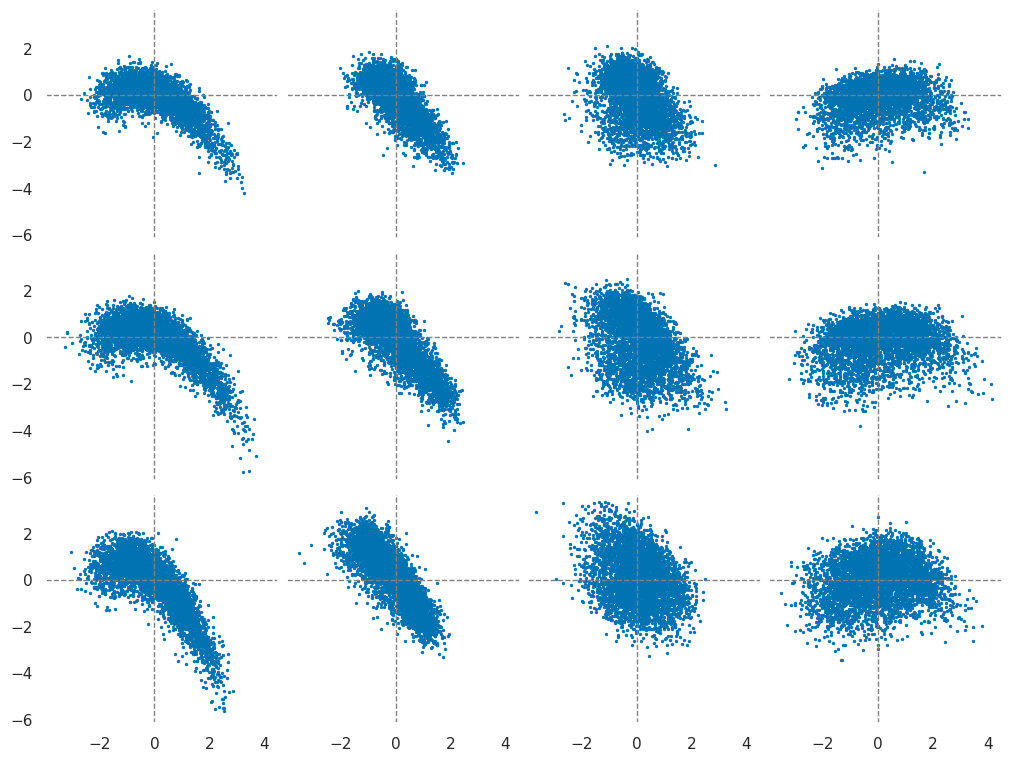

In [87]:
fig, axs = plt.subplots(3, 4, figsize=(10, 7.5), layout="constrained")


## loop thru years
for yi, y in enumerate([1870, 2010, 2080]):

    ## get data for given year
    # Th_y = Th_rolling.sel(year=y).resample({"time":"QS-JAN"}).mean()
    Th_y = Th_rolling.sel(year=y)

    ## loop thru months
    for mi, m_idx in enumerate(np.arange(1, 13, 3)):

        ## subset for month
        is_m = Th_y.time.dt.month == m_idx
        Th_ym = Th_y.isel(time=is_m)

        ## plot data
        axs[yi, mi].scatter(Th_ym[varnames[0]], Th_ym[varnames[1]], s=2)

        ## formatting
        ax_kwargs = dict(ls="--", lw=1, c="gray")
        axs[yi, mi].axvline(0, **ax_kwargs)
        axs[yi, mi].axhline(0, **ax_kwargs)

src.utils.set_lims(axs)
for ax in axs[:-1].flatten():
    ax.set_xticks([])
for ax in axs[:, 1:].flatten():
    ax.set_yticks([])
plt.show()

### validate

In [99]:
# simulation specs
simulation_kwargs = dict(
    nyear=40,
    ncopy=500,
    seed=1000,
    X0_ds=Th_rolling[varnames].isel(year=0, member=0, time=0),
    # X0_ds = None,
    noise_type="white",
    use_noise_cov=True,
    is_xi_stdac=True,
    noise_scale=1.35, ## use for h_w
    # noise_scale=1.45, ## use for h_hat
)

In [100]:
## do simulations
sims = get_sims_over_time(model=MODEL, params=fits, **simulation_kwargs)

## resample to DJF
get_djf = lambda x: x.resample({"time": "QS-DEC"}).mean().isel(time=slice(4, -4, 4))

## resample to seasonal
sims_djf = get_djf(sims)
Th_djf = get_djf(Th_rolling[varnames])

 95%|█████████▌| 21/22 [00:14<00:00,  1.49it/s]/glade/u/home/kcarr/RO-change-over-time/src/XRO.py:1239: RuntimeWarning: overflow encountered in square
  b[:, None] * X**2
/glade/u/home/kcarr/RO-change-over-time/src/XRO.py:1239: RuntimeWarning: invalid value encountered in multiply
  b[:, None] * X**2
/glade/u/home/kcarr/RO-change-over-time/src/XRO.py:1240: RuntimeWarning: overflow encountered in power
  + c[:, None] * X**3
/glade/u/home/kcarr/RO-change-over-time/src/XRO.py:1240: RuntimeWarning: invalid value encountered in multiply
  + c[:, None] * X**3
/glade/u/home/kcarr/RO-change-over-time/src/XRO.py:1628: RuntimeWarning: overflow encountered in multiply
  RO_T2 = X[0,] * X[0,]
/glade/u/home/kcarr/RO-change-over-time/src/XRO.py:1629: RuntimeWarning: overflow encountered in multiply
  RO_TH = X[0,] * X[1,]
/glade/u/home/kcarr/RO-change-over-time/src/XRO.py:1630: RuntimeWarning: overflow encountered in multiply
  RO_T3 = X[0,] * X[0,] * X[0,]
/glade/u/home/kcarr/RO-change-over-time/sr

### Compute stats

In [101]:
def get_std(x):
    return x.std(["time", "member"])


def get_quantiles(x):
    return x.quantile(dim=["time", "member"], q=[0.05, 0.1, 0.5, 0.9, 0.95])


def get_stats(x):
    """compute relevant stats for given dataset"""

    ## empty dataset to hold results
    stats = xr.Dataset()

    ## helper func to convert to xr.DataArray
    to_da = lambda x: x.to_dataarray(dim="v")

    ## compute
    stats["sigma"] = to_da(get_std(x))
    stats["q"] = to_da(get_quantiles(x))

    return stats

In [102]:
stats_ro = get_stats(sims_djf)
stats_gt = get_stats(Th_djf)

### Plot results

#### Quantiles

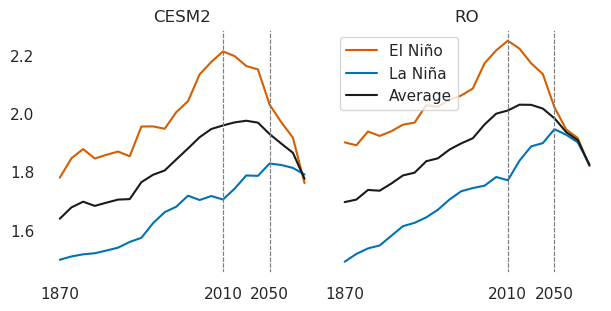

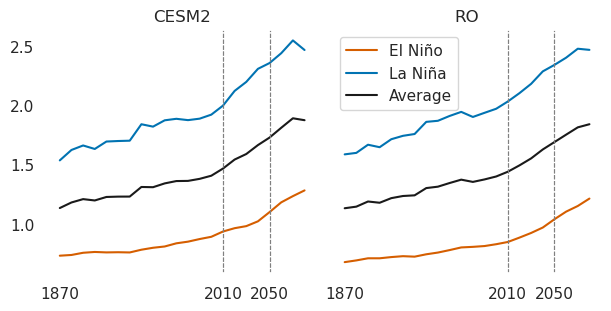

In [103]:
for varname in varnames:

    fig, axs = plt.subplots(1, 2, figsize=(6, 3), layout="constrained")
    for ax, stats_ in zip(axs, [stats_gt, stats_ro]):
        q = stats_["q"].sel(v=varname)

        ax.plot(stats_.year, q.sel(quantile=0.95), c="r", label="El Niño")
        ax.plot(stats_.year, -q.sel(quantile=0.05), c="b", label="La Niña")
        ax.plot(
            stats_.year,
            0.5 * (q.sel(quantile=0.95) - q.sel(quantile=0.05)),
            label="Average",
            c="k",
        )

        ax_kwargs = dict(ls="--", c="gray", lw=0.8)
        src.utils.add_vticks(axs, xticks=[1870, 2010, 2050], xlines=[2010, 2050])
        # ax.set_ylim([0, None])

    src.utils.set_lims(axs)
    axs[1].set_yticks([])
    axs[1].legend()
    axs[0].set_title("CESM2")
    axs[1].set_title("RO")
    plt.show()

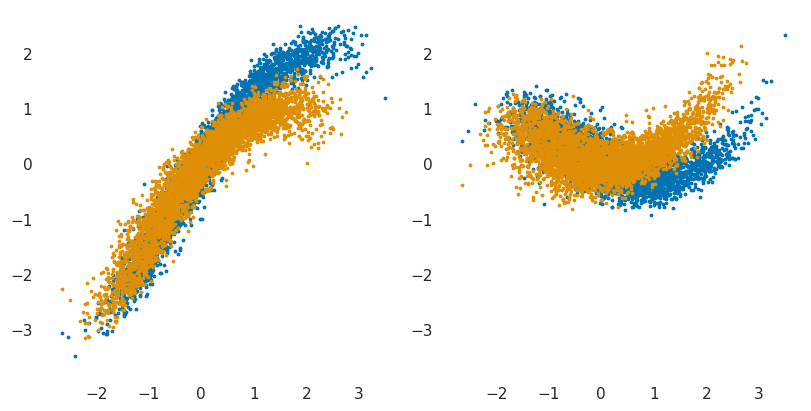

In [104]:
Th_ = Th_rolling.resample({"time": "QS-JAN"}).mean().isel(time=slice(4, -4, 4))

fig, axs = plt.subplots(1, 2, figsize=(8, 4), layout="constrained")
for ax, yr in zip(axs, [2010, 2080]):
    axs[0].scatter(
        Th_["T_e"].sel(year=yr),
        Th_["T_w"].sel(year=yr),
        s=3,
    )
    axs[1].scatter(
        Th_["T_e"].sel(year=yr),
        Th_["T_e"].sel(year=yr) - Th_["T_w"].sel(year=yr),
        s=3,
    )

src.utils.set_lims(axs)

#### PDFs

In [105]:
def get_pdf(x, year, varname=varnames[0], amp=4):
    """compute pdf for given data"""

    ## get edges
    edges = np.linspace(-amp, amp, 20)

    ## reshape data
    x_ = x[varname].sel(year=year).stack(s=["time", "member"]).values

    ## compute
    pdf, _ = src.utils.get_empirical_pdf(x_, edges=edges)

    return pdf, edges

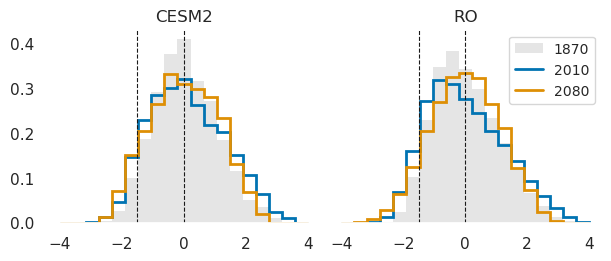

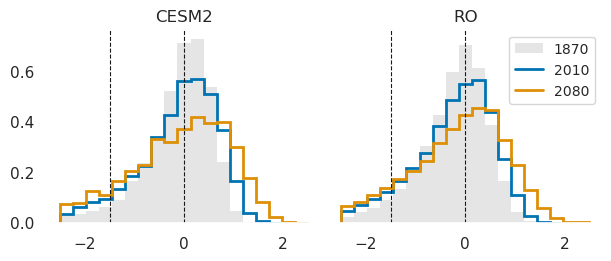

In [106]:
for PLOT_VAR, a in zip(varnames, [4, 2.5]):

    fig, axs = plt.subplots(1, 2, figsize=(6, 2.5), layout="constrained")

    for ax, x, title in zip(axs, [Th_djf, sims_djf], ["CESM2", "RO"]):

        for y, kwargs in zip(
            [1870, 2010, 2080],
            [dict(color="gray", fill=True, alpha=0.2), dict(lw=2), dict(lw=2)],
        ):

            ## compute pdf for given year
            pdf_y, edges = get_pdf(x, year=y, varname=PLOT_VAR, amp=a)

            ## plot
            ax.stairs(pdf_y, edges, label=y, **kwargs)

        ## label/format
        ax.set_title(title)
        # ax.set_xlim([-3.3, 3.3])
        # ax.set_xticks([-3, 0, 3])
        ax_kwargs = dict(ls="--", c="k", lw=0.8)
        ax.axvline(0, **ax_kwargs)
        ax.axvline(-1.5, **ax_kwargs)

    ## formatting
    src.utils.set_lims(axs)
    axs[1].set_yticks([])
    axs[1].legend(prop=dict(size=10))
    plt.show()

### Variance/skewness over time

In [107]:
get_sigma = lambda x: x.std("time").quantile(dim="member", q=[0.1, 0.5, 0.9])
sigma_mod = get_sigma(Th_djf)
sigma_sim = get_sigma(sims_djf)

In [108]:
## compute stats
get_stat = lambda x, fn: xr.apply_ufunc(
    fn, x, input_core_dims=[["time"]], kwargs={"axis": -1}
)
get_stat_wrapper = lambda x, fn: get_stat(x, fn).quantile(
    dim="member", q=[0.1, 0.5, 0.9]
)

# median_ot = get_stat(Th_djf, np.median)
skew_mod = get_stat_wrapper(Th_djf, scipy.stats.skew)
skew_sim = get_stat_wrapper(sims_djf, scipy.stats.skew)
# std_ot = get_stat(Th_djf, np.std)
# m3_ot = skew_ot * (std_ot**3)

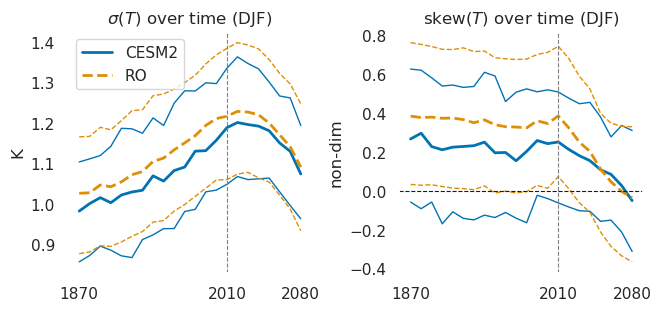

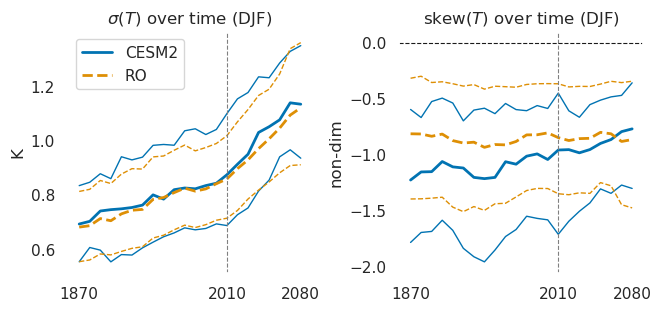

In [109]:
## specify colors
colors = sns.color_palette()

for PLOT_VAR in varnames:

    ## plot setup
    fig, axs = plt.subplots(1, 2, figsize=(6.5, 3), layout="constrained")

    ## plot data
    for ax, stats in zip(axs, [[sigma_mod, sigma_sim], [skew_mod, skew_sim]]):
        for stat, c, ls, label in zip(stats, colors, ["-", "--"], ["CESM2", "RO"]):
            for q, lw in zip([0.5, 0.1, 0.9], [2, 1, 1]):
                label_ = label if (q == 0.5) else None
                ax.plot(
                    stat.year,
                    stat[PLOT_VAR].sel(quantile=q),
                    c=c,
                    lw=lw,
                    ls=ls,
                    label=label_,
                )

    src.utils.add_vticks(axs, xticks=[1870, 2010, 2080], xlines=[2010])

    axs[0].legend()
    axs[1].axhline(0, ls="--", c="k", lw=0.8)
    axs[0].set_ylabel("K")
    axs[1].set_ylabel("non-dim")
    axs[0].set_title(r"$\sigma(T)$ over time (DJF)")
    axs[1].set_title(r"skew$(T)$ over time (DJF)")
    plt.show()

CESM2:


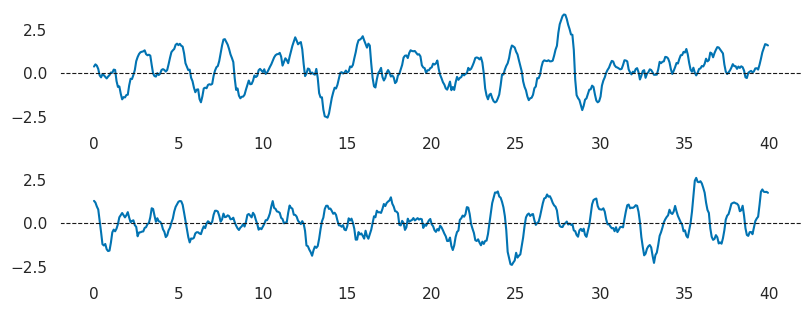


Simulated:


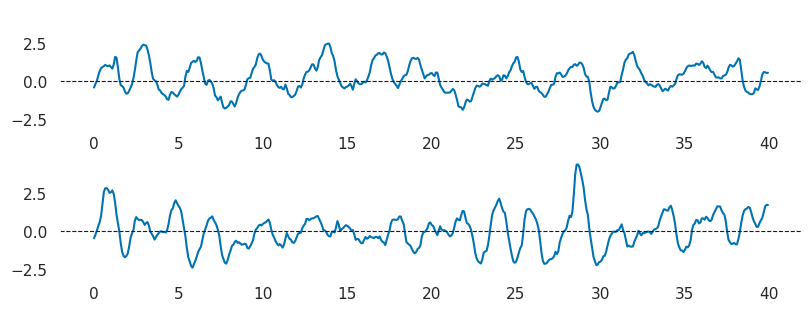

In [110]:
PLOT_VAR = varnames[0]

print(f"CESM2:")
fig, axs = plt.subplots(2, 1, figsize=(8, 3), layout="constrained")
axs[0].plot(np.arange(0, 40, 1 / 12), Th_rolling[PLOT_VAR].isel(member=9, year=10))
axs[1].plot(np.arange(0, 40, 1 / 12), Th_rolling[PLOT_VAR].isel(member=10, year=-1))
src.utils.set_lims(axs)
for ax in axs:
    ax.axhline(0, ls="--", c="k", lw=0.8)
plt.show()

print(f"\nSimulated:")
fig, axs = plt.subplots(2, 1, figsize=(8, 3), layout="constrained")
axs[0].plot(np.arange(0, 40, 1 / 12), sims[PLOT_VAR].isel(member=9, year=10))
axs[1].plot(np.arange(0, 40, 1 / 12), sims[PLOT_VAR].isel(member=10, year=-1))
src.utils.set_lims(axs)
for ax in axs:
    ax.axhline(0, ls="--", c="k", lw=0.8)
plt.show()

### look at noise

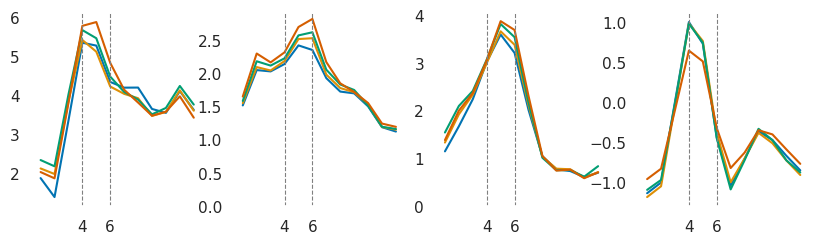

In [111]:
# delta =

xi = fits["xi_stdac"].isel(ranky=0)
R = fits["Lac"].isel(ranky=0, rankx=0) - fits["Lac"].isel(ranky=1, rankx=1)
F1 = fits["Lac"].isel(ranky=0, rankx=1)
F2 = -fits["Lac"].isel(ranky=1, rankx=0)
# beta= fits["NROT_Lac"].isel(nro_form=-1)
beta = fits["NROH_Lac"].isel(nro_form=0)
dxi = xi / xi.isel(year=0) - 1
dR = R / R.isel(year=0) - 1

fig, axs = plt.subplots(1, 4, figsize=(10, 2.5))
for ax, p in zip(axs, [R, xi, F1, beta]):

    for y in [1870, 1910, 1950, 1990]:

        ax.plot(params.cycle, p.sel(year=y))

axs[1].set_ylim([0, None])
axs[2].set_ylim([0, None])
src.utils.add_vticks(axs, xlines=[4, 6], xticks=[4, 6])

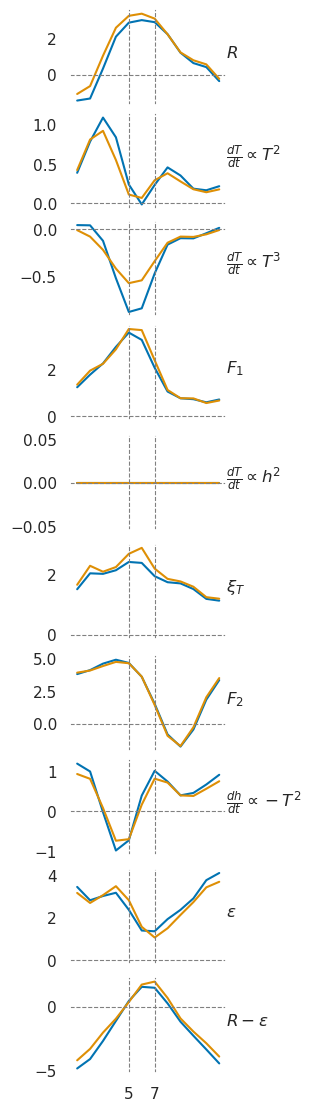

In [112]:
BJ = fits["Lac"].isel(rankx=0, ranky=0) + fits["Lac"].isel(rankx=1, ranky=1)

fig, axs = plt.subplots(10, 1, figsize=(3, 11), layout="constrained")
for y in [1880, 2010]:  # , 2030, 2080]:
    axs[0].plot(fits.cycle, fits["Lac"].isel(rankx=0, ranky=0).sel(year=y), label=y)
    axs[1].plot(fits.cycle, fits["NROT_Lac"].isel(nro_form=0).sel(year=y), label=y)
    axs[2].plot(fits.cycle, fits["NROT_Lac"].isel(nro_form=2).sel(year=y), label=y)
    axs[3].plot(fits.cycle, fits["Lac"].isel(ranky=0, rankx=1).sel(year=y), label=y)
    axs[4].plot(fits.cycle, fits["NROT_Lac"].isel(nro_form=-1).sel(year=y), label=y)
    axs[5].plot(fits.cycle, fits["xi_stdac"].isel(ranky=0).sel(year=y), label=y)
    axs[6].plot(fits.cycle, -fits["Lac"].isel(ranky=1, rankx=0).sel(year=y), label=y)
    axs[7].plot(fits.cycle, -fits["NROH_Lac"].isel(nro_form=0).sel(year=y), label=y)
    axs[8].plot(fits.cycle, -fits["Lac"].isel(rankx=1, ranky=1).sel(year=y), label=y)
    # axs[9].plot(fits.cycle, -fits["NLb_Lac"].isel(ranky=1).sel(year=y), label=y)
    axs[9].plot(fits.cycle, BJ.sel(year=y), label=y)


src.utils.add_vticks(axs, xlines=fits.cycle.values[[4, 6]], xticks=[])
kwargs = dict(x=1.0, y=0.5)
axs[0].text(s=r"$R$", transform=axs[0].transAxes, **kwargs)
axs[1].text(s=r"$\frac{dT}{dt}\propto T^2$", transform=axs[1].transAxes, **kwargs)
axs[2].text(s=r"$\frac{dT}{dt}\propto T^3$", transform=axs[2].transAxes, **kwargs)
axs[3].text(s=r"$F_1$", transform=axs[3].transAxes, **kwargs)
axs[4].text(s=r"$\frac{dT}{dt}\propto h^2$", transform=axs[4].transAxes, **kwargs)
axs[5].text(s=r"$\xi_T$", transform=axs[5].transAxes, **kwargs)
axs[6].text(s=r"$F_2$", transform=axs[6].transAxes, **kwargs)
axs[7].text(s=r"$\frac{dh}{dt}\propto -T^2$", transform=axs[7].transAxes, **kwargs)
axs[8].text(s=r"$\varepsilon$", transform=axs[8].transAxes, **kwargs)
# axs[9].text(s=r"$\frac{dh}{dt}\propto -h^2$", transform=axs[9].transAxes, **kwargs)
axs[9].text(s=r"$R-\varepsilon$", transform=axs[9].transAxes, **kwargs)
for ax in axs:
    ax.axhline(0, ls="--", c="gray", lw=0.8)
# ax.legend()

axs[-1].set_xticks(fits.cycle.values[[4, 6]], labels=[5, 7])
plt.show()

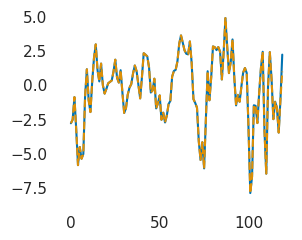

In [113]:
## check fits make sense
idx = dict(year=2, member=0, time=slice(None, 120))

## make plot
fig, ax = plt.subplots(figsize=(3, 2.5))
ax.plot(fits["Y"].isel(ranky=0, **idx))
ax.plot(get_ddt(Th_rolling[varnames[0]].isel(**idx)), ls="--")
plt.show()

In [114]:
## resample to AMJ
fit_amj = fits.resample({"time": "QS-JAN"}).mean().isel(time=slice(1, -4, 4))
fit_amj0 = fit_amj.sel(year=1880)
fit_amj1 = fit_amj.sel(year=1990)

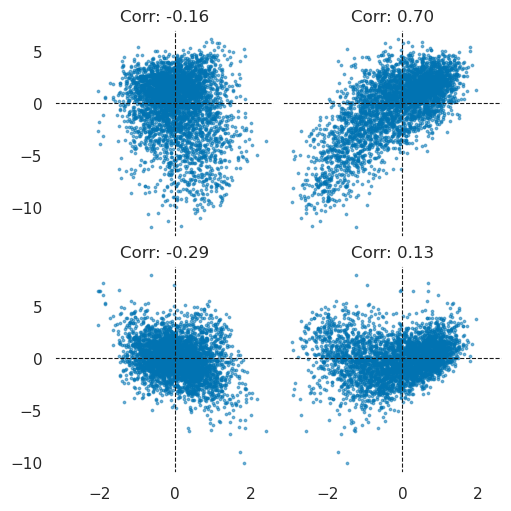

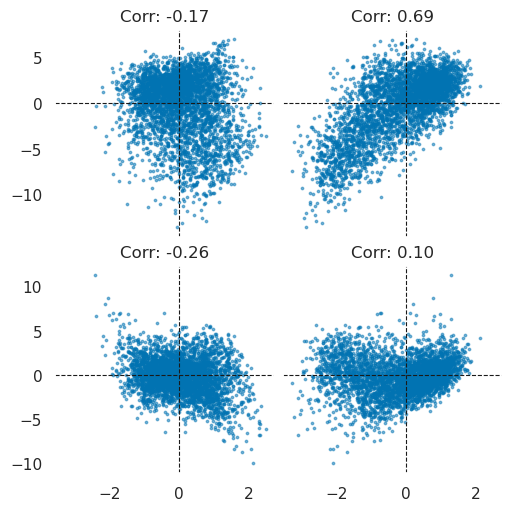

In [115]:
for fit_amj_ in [fit_amj0, fit_amj1]:

    fig, axs = plt.subplots(2, 2, figsize=(5, 5), layout="constrained")

    ## loop thru (actual, error)
    for j, v in enumerate(["Y", "error"]):

        for xi, ax in enumerate(axs[j]):

            x0 = fit_amj_["X"].isel(rankx=xi)
            x1 = fit_amj_[v].isel(ranky=0)
            # x1 = fit_amj_[v].isel(ranky=1)

            ax.scatter(x0, x1, s=3, alpha=0.5)
            corr = xr.corr(x0, x1).values.item()
            ax.set_title(f"Corr: {corr:.2f}")

            ## format
            ax_kwargs = dict(ls="--", c="k", lw=0.8)
            ax.axhline(0, **ax_kwargs)
            ax.axvline(0, **ax_kwargs)

        src.utils.set_lims(axs[j])
        axs[j, 1].set_yticks([])

    for ax in axs[0]:
        ax.set_xticks([])

    plt.show()

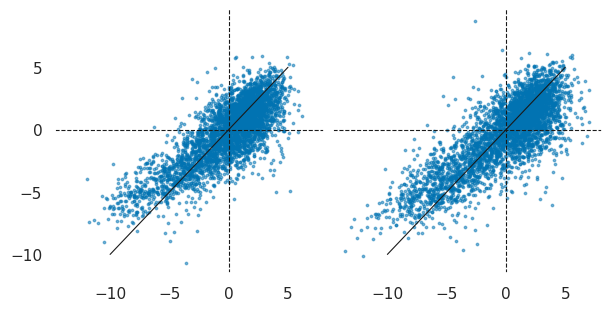

In [116]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3), layout="constrained")

for ax, year in zip(axs, [1880, 1990]):
    ax.scatter(
        fit_amj["Y"].isel(ranky=0).sel(year=year),
        fit_amj["Yfit"].isel(ranky=0).sel(year=year),
        s=3,
        alpha=0.5,
    )

    ## format
    ax_kwargs = dict(ls="--", c="k", lw=0.8)
    ax.axhline(0, **ax_kwargs)
    ax.axvline(0, **ax_kwargs)
    zz = np.linspace(-10, 5)
    ax.plot(zz, zz, ls="-", lw=0.8, c="k")

axs[1].set_yticks([])
src.utils.set_lims(axs)

plt.show()

Correlation with SST

In [117]:
## get SST data to match
anom_ = src.utils.get_windowed(
    anom[["T", "sst"]], window_size=480, stride=120
).compute()

print("Here")
anom_ = anom_.isel(year=slice(None, -1))
anom_ = xr.merge([anom_, Th_rolling])

## resample to AMJ
anom_amj = anom_.resample({"time": "QS-JAN"}).mean().isel(time=slice(1, None, 4))
anom_jfm = anom_.resample({"time": "QS-JAN"}).mean().isel(time=slice(0, None, 4))
anom_jfm = anom_jfm.assign_coords({"time": anom_amj.time})

print("Here")
## add error to spatial arrays
anom_amj["error"] = fit_amj["error"].isel(ranky=0)
anom_amj["error_amp"] = fit_amj["error_amp"].isel(ranky=0)
anom_jfm["error"] = fit_amj["error"].isel(ranky=0)
anom_jfm["error_amp"] = fit_amj["error_amp"].isel(ranky=0)

## compute SPMM
anom_amj["spmm"] = src.utils.reconstruct_fn(
    scores=anom_amj["sst"],
    components=anom["sst_comp"],
    fn=lambda x: x.sel(latitude=slice(-15, -5), longitude=slice(210, 270)).mean(
        ["latitude", "longitude"]
    ),
)

## check it mathces
print(f"{xr.corr(anom_amj["T_3"], fit_amj["X"].isel(rankx=0)).values.item():.4f}")

Here
Here
1.0000


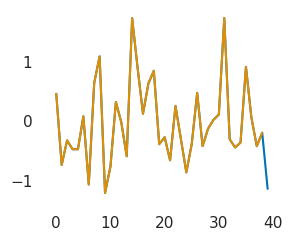

In [118]:
fig, ax = plt.subplots(figsize=(3, 2.5))
ax.plot(anom_amj["T_3"].isel(idx))
ax.plot(fit_amj["X"].isel(rankx=0).isel(idx))
plt.show()

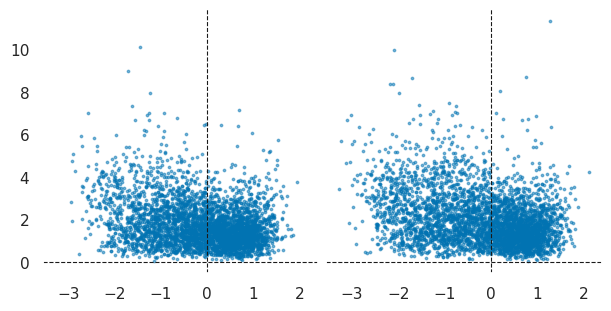

In [119]:
fig, axs = plt.subplots(1, 2, figsize=(6, 3), layout="constrained")

for ax, year in zip(axs, [1880, 1990]):
    ax.scatter(
        # anom_jfm["T_34"].sel(year=year),
        anom_amj[varnames[1]].sel(year=year),
        anom_amj["error_amp"].sel(year=year),
        # anom_amj["error"].sel(year=year),
        s=3,
        alpha=0.5,
    )

    ## format
    ax_kwargs = dict(ls="--", c="k", lw=0.8)
    ax.axhline(0, **ax_kwargs)
    ax.axvline(0, **ax_kwargs)
    # zz=np.linspace(-10,5)
    # ax.plot(zz,zz,ls="-", lw=.8, c="k")

axs[1].set_yticks([])
src.utils.set_lims(axs)

plt.show()

In [120]:
for a_ in [anom_jfm, anom_amj]:
    print(
        xr.corr(
            a_[["T_4", "T_34", "T_3", "h", "h_w", varnames[1]]].to_dataarray(),
            a_["error_amp"],
            # a_["error"],
            dim=["time", "member"],
        )
        .isel(year=1)
        .values
    )
    print()

[ 0.19618649  0.24189025  0.26095202  0.00595636 -0.26499285]

[ 0.09269296  0.13724571  0.16022489 -0.24075878 -0.27687908]



In [121]:
is_pos = anom_amj[varnames[1]] <= 0
is_neg = anom_amj[varnames[1]] >= 0
error_amp_pos = anom_amj["error_amp"].where(is_pos).mean(["time"])
error_amp_neg = anom_amj["error_amp"].where(is_neg).mean(["time"])

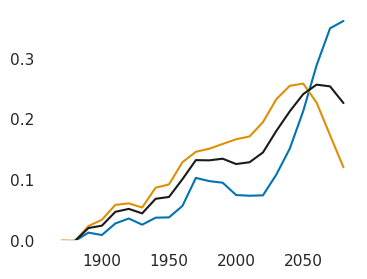

In [122]:
delta = lambda x: x / x.isel(year=1) - 1
# delta = lambda x : x
fig, ax = plt.subplots(figsize=(4, 3))
ax.plot(anom_amj.year, delta(error_amp_neg.mean("member")))
ax.plot(anom_amj.year, delta(error_amp_pos.mean("member")))
ax.plot(anom_amj.year, delta(anom_amj["error_amp"].mean(["time", "member"])), c="k")
ax.set_ylim([0, None])
plt.show()

#### Regress on error

In [123]:
## regress on error
m_error = src.utils.regress_xr_proj(
    # data=anom_jfm,
    # x_vars=["error_amp"],
    data=anom_amj,
    x_vars=["error_amp"],
    y_vars=["sst", "T"],
    # x_vars=["error"],
).squeeze(drop=True)

## get spatial patterns
m_error = src.utils.reconstruct_wrapper(
    xr.merge([m_error, anom[["T_comp", "sst_comp"]]]),
    fn=lambda x: x,
)

#### Plot

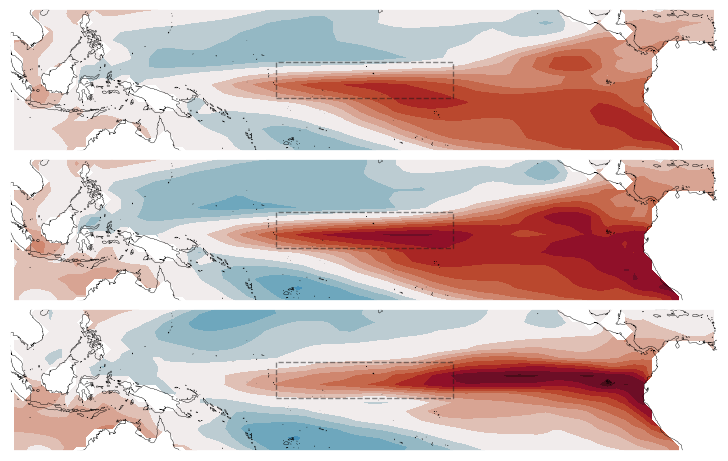

In [124]:
import cartopy.crs as ccrs

fig = plt.figure(figsize=(8, 4.5), layout="constrained")
format_func = lambda ax,: src.utils.plot_setup_pac(ax, max_lat=20)
axs = src.utils.subplots_with_proj(fig, nrows=3, ncols=1, format_func=format_func)

kwargs = dict(
    cmap="cmo.balance",
    transform=ccrs.PlateCarree(),
    levels=src.utils.make_cb_range(0.3, 0.03),
    extend="both",
)

for j, y in enumerate([1880, 2000]):

    axs[j, 0].contourf(
        m_error.longitude,
        m_error.latitude,
        m_error["sst"].sel(year=y),
        **kwargs,
    )

axs[-1, 0].contourf(
    m_error.longitude,
    m_error.latitude,
    3 * (m_error["sst"].sel(year=2000) - m_error["sst"].sel(year=1880)),
    **kwargs,
)


for ax in axs[:, 0]:
    # src.utils.plot_nino34_box(ax, c="k", lw=1, ls="--",alpha=.5)
    src.utils.plot_box(
        ax, lats=[-5, 5], lons=[175, 225], c="k", lw=1, ls="--", alpha=0.5
    )
plt.show()

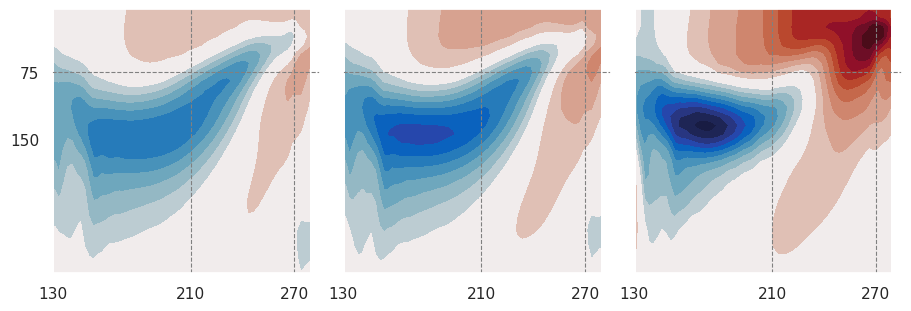

In [125]:
fig, axs = plt.subplots(1, 3, figsize=(9, 3), layout="constrained")

kwargs = dict(
    cmap="cmo.balance", levels=src.utils.make_cb_range(0.8, 0.08), extend="both"
)

for ax, y in zip(axs, [1880, 2000]):

    ax.contourf(m_error.longitude, m_error.z_t, m_error["T"].sel(year=y), **kwargs)

axs[-1].contourf(
    m_error.longitude,
    m_error.z_t,
    6 * (m_error["T"].sel(year=2000) - m_error["T"].sel(year=1880)),
    **kwargs
)

for ax in axs:
    ax.set_ylim([300, 5])
    ax.set_xlim([130, 285])
    ax.set_yticks([])
    ax.axhline(75, ls="--", c="gray", lw=0.8)

axs[0].set_yticks([75, 150])
src.utils.add_vticks(axs, xlines=[210, 270], xticks=[130, 210, 270])
plt.show()

### Extract params

Get coefficients

In [126]:
## get coefficients
coefs_nl = fits["NROT_Lac"].sel(nro_form=["T2", "T3"])
R = fits["Lac"].isel(ranky=0, rankx=0).expand_dims(nro_form=["T"])
eps = -fits["Lac"].isel(ranky=1, rankx=1)
coefs = xr.concat([R, coefs_nl], dim="nro_form").rename({"nro_form": "form"})

Compute feature matrix for reconstructing nonlinear $R$

In [127]:
## how should we scale the feature matrix?
## One of {"constant", "by_month", "sliding_by_month"}
SCALE_TYPE = "by_month"

## get scale
sigma_T = Th_rolling["T_3"].groupby("time.month").std(["time", "member"])

## average as needed
if SCALE_TYPE == "constant":
    sigma_T = sigma_T.mean(["year", "month"]) * xr.ones_like(sigma_T)

elif SCALE_TYPE == "by_month":
    sigma_T = sigma_T.mean("year") * xr.ones_like(sigma_T)

## update coordinate names to match
sigma_T = sigma_T.rename({"month": "cycle"}).assign_coords({"cycle": fits["cycle"]})

## scale feature mat by sigma_T
z = np.arange(-3, 3.1, 0.1)
z = xr.DataArray(z, coords=dict(sigma=z))
Z = sigma_T * z.expand_dims({"year": fits.year, "cycle": sigma_T.cycle})

## expand to get coefficients
Z = xr.concat([Z**i for i in range(3)], dim=coefs.form)

## check everything makes sense
print(np.allclose(Z.sel(form="T2").sel(sigma=1, method="nearest"), sigma_T))

True


Do the reconstruction

In [128]:
## reconstruct nonlinear R
R_nl = (coefs * Z).sum("form")
R_nl_ann = R_nl.mean("cycle")
eps_ann = eps.mean("cycle")

## Compute time-varying alpha

### Fits

In [129]:
def psi_(x, a, b, c):
    """base transfer function"""
    return c * np.exp(a * x) + b


def get_psi(x, y):
    """get transfer function from data"""

    ## prep data
    stack = lambda x: x.stack(s=["time", "member"]).values
    x_ = stack(x)
    y_ = stack(y)

    ## get parameter fit
    p, _ = scipy.optimize.curve_fit(
        f=psi_,
        xdata=x_,
        ydata=y_,
        p0=np.array([0.7, 1.7, -1.5]),
        maxfev=2000,
    )

    ## define transfer func
    psi = lambda x: psi_(x, a=p[0], b=p[1], c=p[2])

    ## put parameters in array
    params = xr.DataArray(p, coords=dict(param=["a", "b", "c"])).rename("params")

    return psi, params


def psi_poly(T, c, b, a, e):
    """base transfer function"""
    # return e * x**3 + c * x**2 + b * x + a
    return (c / 3) * T**3 + (b / 2) * T**2 + a * T + e


def get_psi_poly(x, y):
    """get transfer function from data"""

    ## prep data
    stack = lambda x: x.stack(s=["time", "member"]).values
    x_ = stack(x)
    y_ = stack(y)

    ## get parameter fit
    p, _ = scipy.optimize.curve_fit(
        f=psi_poly,
        xdata=x_,
        ydata=y_,
    )

    ## define transfer func
    psi = lambda T: psi_poly(T, c=p[0], b=p[1], a=p[2], e=p[3])

    ## put params in dataarray
    params = xr.DataArray(p, coords=dict(param=["c", "b", "a", "e"])).rename("params")

    return psi, params


def get_psi_wrapper(xy, x_var, y_var, year, get_psi_func=get_psi):
    """get transfer function from data"""

    ## get transfer func
    psi_func, p = get_psi_func(x=xy[x_var].sel(year=year), y=xy[y_var].sel(year=year))

    ## get coefficient array (standardized units)
    z = np.arange(-3, 3.1, 0.1)
    z = xr.DataArray(z, coords=dict(sigma=z))

    ## evaluate function
    psi_eval = xr.zeros_like(z)
    psi_eval.values = psi_func(z.values)

    ## merge eval and params
    return xr.merge([psi_eval.rename("psi_eval"), p])

In [130]:
## specify functional form of alpha
# get_psi_func = get_psi
get_psi_func = get_psi_poly

## empty array to hold alpha
psi_ot = []

## args for curve fit
kwargs = dict(x_var=varnames[0], y_var=Q_VAR, get_psi_func=get_psi_func)

## loop thru
for yr in tqdm.tqdm(Th_rolling.year):

    psi_ot.append(
        Th_rolling.groupby("time.month").map(get_psi_wrapper, year=yr, **kwargs)
    )
    # psi_ot.append(psi_eval)
    # psi_ot.append(
    #     Th_rolling.groupby("time.month").map(get_psi_wrapper, year=yr, **kwargs)
    # )

## concat
psi_ot = xr.concat(psi_ot, dim=Th_rolling.year)

## compute alpha
alpha = -psi_ot.differentiate("sigma")

## update coords to match R
alpha = alpha.rename({"month": "cycle", "psi_eval": "eval"})
alpha["cycle"] = R_nl.cycle

100%|██████████| 22/22 [00:10<00:00,  2.03it/s]


Plot for given month, year

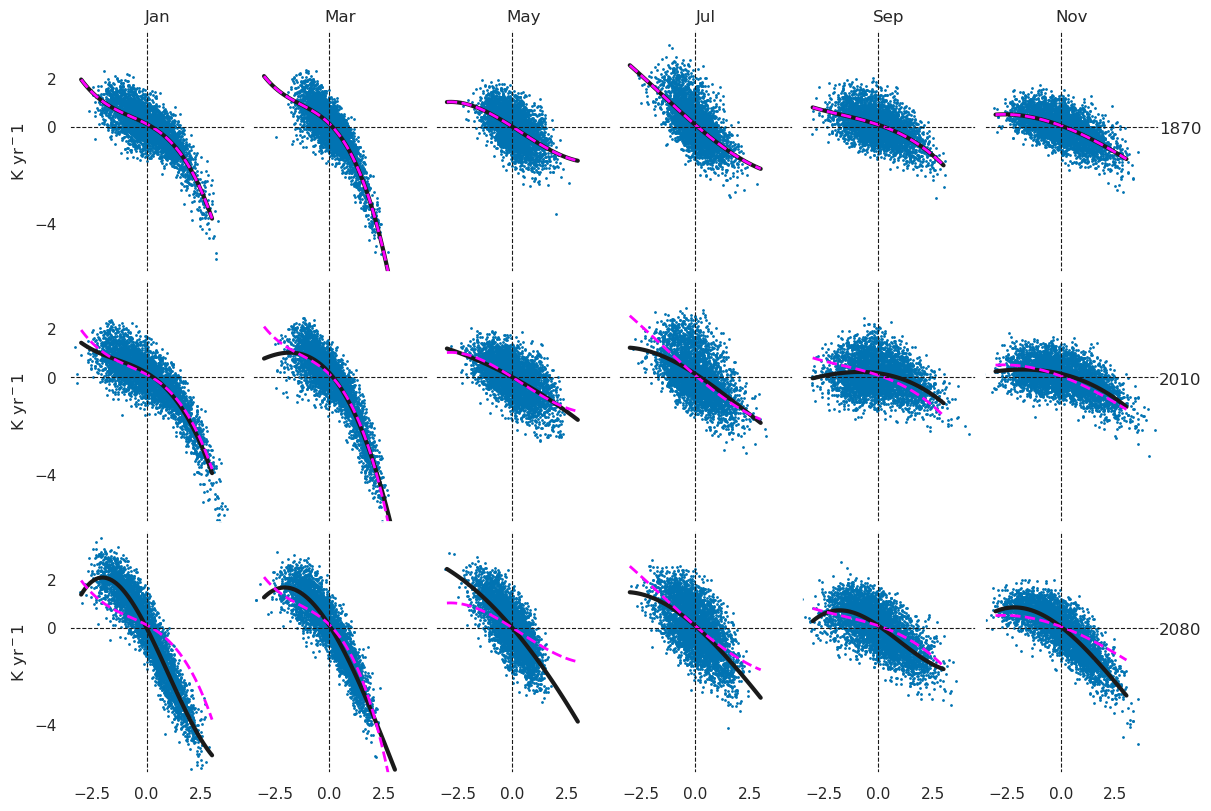

In [131]:
## specify years, months
plot_years = [1870, 2010, 2080]
plot_months = np.arange(1, 13, 2)

## plot data
fig, axs = plt.subplots(
    len(plot_years), len(plot_months), figsize=(12, 8), layout="constrained"
)

for j, plot_year in enumerate(plot_years):

    for ax, m in zip(axs[j], plot_months):
        plot_data = Th_rolling.sel(year=plot_year).isel(time=slice(m - 1, None, 12))
        # ax.scatter(plot_data[varnames[0]], plot_data["Q_m"], s=1)
        ax.scatter(plot_data[varnames[0]], plot_data[Q_VAR], s=1)
        ax.plot(
            psi_ot.sigma, psi_ot["psi_eval"].sel(month=m, year=plot_year), c="k", lw=3
        )
        ax.plot(
            psi_ot.sigma,
            psi_ot["psi_eval"].sel(month=m, year=plot_years[0]),
            c="magenta",
            lw=2,
            ls="--",
        )

        ## formatting
        ax.set_xlim([-3.5, 4.5])
        ax.set_ylim([-6, 4])
        ax.set_yticks([])
        ax_kwargs = dict(ls="--", lw=0.8, c="k")
        ax.axhline(0, **ax_kwargs)
        ax.axvline(0, **ax_kwargs)

src.utils.set_lims(axs.flatten())
for m, ax in zip(plot_months, axs[0, :]):
    ax.set_title(f"{calendar.month_abbr[m]}")

for ax, yr in zip(axs[:, -1], plot_years):
    ax.text(x=4.5, y=-0.3, s=yr)
for ax in axs[:, 0]:
    ax.set_yticks([-4, 0, 2])
    ax.set_ylabel(f"K yr$^{-1}$")
for ax in axs[:-1].flatten():
    ax.set_xticks([])
plt.show()

### Compute $R_o$

In [132]:
## evaluated
Ro = R_nl + alpha["eval"]

## copy of params to hold results
fits_Ro = copy.deepcopy(fits)

## get linear terms
Lac_Ro_xr = fits_Ro["Lac"].transpose("year", "cycle", "ranky", "rankx")
Lac_Ro_np = Lac_Ro_xr.values

## get nonlinear terms
NROT_Lac_Ro_xr = fits_Ro["NROT_Lac"].transpose("year", "cycle", "nro_form")
NROT_Lac_Ro_np = NROT_Lac_Ro_xr.values

## get alpha
get_p = lambda x: x.transpose("year", "cycle").values
alpha_a_np = get_p(alpha["params"].sel(param="a"))
alpha_b_np = get_p(alpha["params"].sel(param="b"))
alpha_c_np = get_p(alpha["params"].sel(param="c"))

## update params
Lac_Ro_np[..., 0, 0] = Lac_Ro_np[..., 0, 0] + alpha_a_np
NROT_Lac_Ro_np[..., 0] = NROT_Lac_Ro_np[..., 0] + alpha_b_np
NROT_Lac_Ro_np[..., 2] = NROT_Lac_Ro_np[..., 2] + alpha_c_np

## compute
fits_Ro["Lac"] = Lac_Ro_np * xr.ones_like(Lac_Ro_xr)
fits_Ro["NROT_Lac"] = NROT_Lac_Ro_np * xr.ones_like(NROT_Lac_Ro_xr)

## transpose so dims match
fits_Ro["NROT_Lac"] = fits_Ro["NROT_Lac"].transpose(*fits["NROT_Lac"].dims)
fits_Ro["Lac"] = fits_Ro["Lac"].transpose(*fits["Lac"].dims)

## get alpha in recharge-osc form
fits_alpha = xr.zeros_like(fits)
fits_alpha[["Lac", "NROT_Lac"]] = (
    fits_Ro[["Lac", "NROT_Lac"]] - fits[["Lac", "NROT_Lac"]]
)

Fix $\alpha$ and $R_o$

In [133]:
## get operator variable names
op_names = ["Lac", "NROT_Lac", "NROH_Lac"]

## compute perturbed (fix alpha)
fits_fixed_alpha = copy.deepcopy(fits_Ro)
fits_fixed_alpha[op_names] = fits_Ro[op_names] - fits_alpha[op_names].isel(year=0)

## fix total ocean dynamics
fits_fixed_Lo = copy.deepcopy(fits_Ro)
fits_fixed_Lo[op_names] = fits_Ro[op_names].isel(year=0) - fits_alpha[op_names]

## fix ocean component of R
fits_fixed_Ro = copy.deepcopy(fits_Ro)

## fix R operator in ocean dyn
fits_fixed_Ro_ = src.utils.get_perturbed_multi(
    idxs=[(0, 0)], params=fits_fixed_Ro, fix_others=False, fix_noise=False
)

## fix nonlinear parts of ocean dyn.
fits_fixed_Ro_ = get_perturbed_NRO(
    nro_form_idx=2, params=fits_fixed_Ro_, nro_type="NROT_Lac"
)
fits_fixed_Ro_ = get_perturbed_NRO(
    nro_form_idx=0, params=fits_fixed_Ro_, nro_type="NROT_Lac"
)

## add back damping
fits_fixed_Ro[op_names] = fits_fixed_Ro_ - fits_alpha[op_names]

Check it works

In [134]:
print(
    np.allclose(
        alpha["params"].sel(param="a"),
        (fits_Ro["Lac"] - fits["Lac"]).isel(rankx=0, ranky=0),
    )
)
print(
    np.allclose(
        alpha["params"].sel(param="b"),
        (fits_Ro["NROT_Lac"] - fits["NROT_Lac"]).isel(nro_form=0),
    )
)
print(
    np.allclose(
        alpha["params"].sel(param="c"),
        (fits_Ro["NROT_Lac"] - fits["NROT_Lac"]).isel(nro_form=2),
    )
)

print(
    np.allclose(
        fits_alpha[["Lac", "NROT_Lac"]].to_dataarray(),
        (fits_Ro[["Lac", "NROT_Lac"]] - fits[["Lac", "NROT_Lac"]]).to_dataarray(),
    )
)

True
True
True
True


### Fix seasonal changes

#### Fix Jan-Jun

In [135]:
## copy of params to hold results
fits_cyc0 = copy.deepcopy(fits)

## LINEAR TERMS
Lac_cyc_xr = fits_cyc0["Lac"].transpose("cycle", "year", ...)
Lac_cyc_np = Lac_cyc_xr.values

## get nonlinear terms
NROT_cyc_xr = fits_cyc0["NROT_Lac"].transpose("cycle", "year", ...)
NROT_cyc_np = NROT_cyc_xr.values

## get nonlinear terms
NROH_cyc_xr = fits_cyc0["NROH_Lac"].transpose("cycle", "year", ...)
NROH_cyc_np = NROH_cyc_xr.values

## fix seasonal cycle
Lac_cyc_np[:6] = Lac_cyc_np[:6, :1]
NROT_cyc_np[:6] = NROT_cyc_np[:6, :1]
NROH_cyc_np[:6] = NROH_cyc_np[:6, :1]

## update xr
fits_cyc0["Lac"] = (Lac_cyc_np * xr.ones_like(Lac_cyc_xr)).transpose(*fits["Lac"].dims)
fits_cyc0["NROT_Lac"] = (NROT_cyc_np * xr.ones_like(NROT_cyc_xr)).transpose(
    *fits["NROT_Lac"].dims
)
fits_cyc0["NROH_Lac"] = (NROH_cyc_np * xr.ones_like(NROH_cyc_xr)).transpose(
    *fits["NROH_Lac"].dims
)

Fix Jul-Aug

In [136]:
## copy of params to hold results
fits_cyc1 = copy.deepcopy(fits)

## LINEAR TERMS
Lac_cyc_xr = fits_cyc1["Lac"].transpose("cycle", "year", ...)
Lac_cyc_np = Lac_cyc_xr.values

## get nonlinear terms
NROT_cyc_xr = fits_cyc1["NROT_Lac"].transpose("cycle", "year", ...)
NROT_cyc_np = NROT_cyc_xr.values

## get nonlinear terms
NROH_cyc_xr = fits_cyc1["NROH_Lac"].transpose("cycle", "year", ...)
NROH_cyc_np = NROH_cyc_xr.values

## fix seasonal cycle
Lac_cyc_np[6:] = Lac_cyc_np[6:, :1]
NROT_cyc_np[6:] = NROT_cyc_np[6:, :1]
NROH_cyc_np[6:] = NROH_cyc_np[6:, :1]

## update xr
fits_cyc1["Lac"] = (Lac_cyc_np * xr.ones_like(Lac_cyc_xr)).transpose(*fits["Lac"].dims)
fits_cyc1["NROT_Lac"] = (NROT_cyc_np * xr.ones_like(NROT_cyc_xr)).transpose(
    *fits["NROT_Lac"].dims
)
fits_cyc1["NROH_Lac"] = (NROH_cyc_np * xr.ones_like(NROH_cyc_xr)).transpose(
    *fits["NROH_Lac"].dims
)

## Plot params over time

In [137]:
def add_vticks(axs, xticks, xlines=None):
    """add vertical lines to axs"""

    ## specify line style
    ax_kwargs = dict(ls="--", c="gray", lw=0.8)

    ## loop thru axs
    for ax in axs:
        ax.set_xticks(xticks)
        if xlines is not None:
            for x0 in xlines:
                ax.axvline(x0, **ax_kwargs)

    return

Plot snapshots of growth rate over time. Also, plot seasonal cycle.

In [138]:
## specify where to evaluate R value
T0 = 1.5

if T0 is None:
    """for this case: average over all pos/neg values"""
    R_pos = R_nl.where(R_nl["sigma"] > 0).mean("sigma")
    R_neg = R_nl.where(R_nl["sigma"] < 0).mean("sigma")
    R_all = R_nl.mean("sigma")

else:
    """for this case: find R at given sigma value"""
    R_pos = R_nl.sel(sigma=T0, method="nearest")
    R_neg = R_nl.sel(sigma=-T0, method="nearest")
    R_all = R_nl.sel(sigma=0, method="nearest")

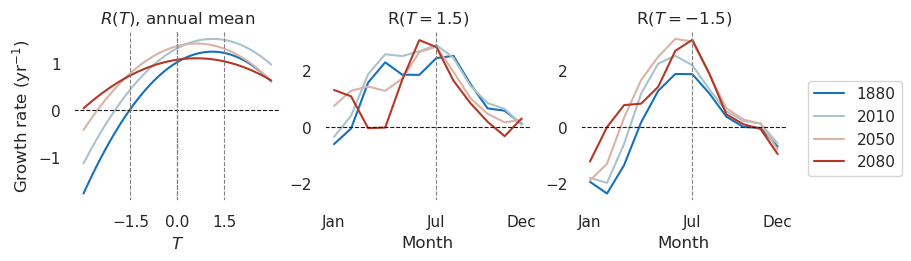

In [139]:
YEARS = np.array([1880, 2010, 2050, 2080])
colors = cmocean.cm.balance(np.linspace(0.2, 0.8, len(YEARS)))

fig, axs = plt.subplots(1, 3, figsize=(9, 2.5), layout="constrained")

for c, y in zip(colors, YEARS):

    ## plot R nonlinearity
    axs[0].plot(R_nl["sigma"], R_nl_ann.sel(year=y), c=c, label=y)
    # axs[0].plot(R_nl["sigma"], (xr.ones_like(R_nl_ann)-eps.mean("cycle")).sel(year=y), c=c, label=y)
    # axs[0].plot(R_nl["sigma"], (R_nl_ann - eps.mean("cycle")).sel(year=y), c=c, label=y)

    ## plot R seasonal cycle
    axs[1].plot(
        # params.cycle,
        # 0.5 * (R_pos - eps).sel(year=y).squeeze(drop=True),
        # # -0.5 * (eps).sel(year=y).squeeze(drop=True),
        # c=c,
        # label=y,
        params.cycle,
        R_pos.sel(year=y).squeeze(drop=True),
        c=c,
        label=y,
    )
    axs[2].plot(
        # params.cycle,
        # 0.5 * (R_neg - eps).sel(year=y).squeeze(drop=True),
        # c=c,
        # label=y,
        params.cycle,
        R_neg.sel(year=y).squeeze(drop=True),
        c=c,
        label=y,
    )


ax_kwargs = dict(ls="--", c="k", lw=0.8)
axs[0].axvline(0, **ax_kwargs)

axs[0].set_xlabel(r"$T$")
axs[0].set_ylabel(r"Growth rate (yr$^{-1}$)")
axs[0].set_title(r"$R(T)$, annual mean")
axs[1].set_title(f"R($T=${T0:.1f})")
axs[2].set_title(f"R($T=-${T0:.1f})")
axs[2].legend(loc=(1.1, 0.15))

for ax in axs:
    ax.axhline(0, **ax_kwargs)

add_vticks(axs[1:], xticks=[1, 7, 12], xlines=[7])
for ax in axs[1:]:
    ax.set_xlabel("Month")
    ax.set_xticks([1, 7, 12], labels=["Jan", "Jul", "Dec"])

src.utils.set_lims(axs[1:])
if T0 is not None:
    add_vticks(axs[:1], xticks=[-T0, 0, T0], xlines=[-T0, 0, T0])

save(fig, fname="gr-cycle", do_save=False)

plt.show()

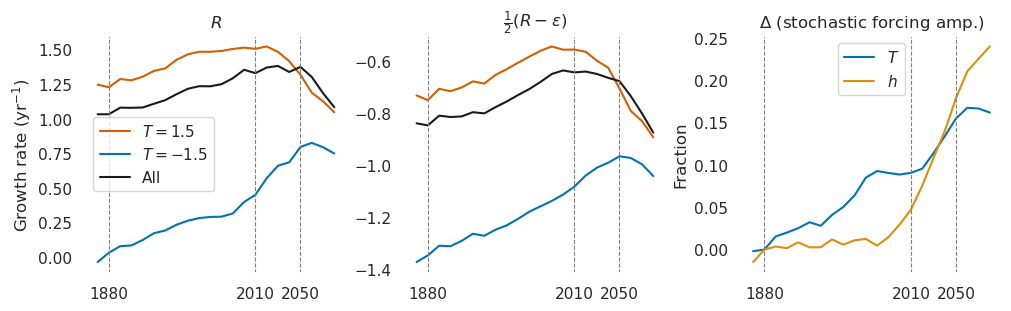

In [140]:
## select cycle
# SEL_CYCLE = lambda x: x.isel(cycle=slice(9, 12)).mean("cycle")
# SEL_CYCLE = lambda x: x.isel(cycle=[7,8,9]).mean("cycle")
# SEL_CYCLE = lambda x: x.isel(cycle=slice(6,None)).mean("cycle")
SEL_CYCLE = lambda x: x.mean("cycle")

fig, axs = plt.subplots(1, 3, figsize=(10, 3), layout="constrained")

## plot R and R-epsilon
for R_, c, label in zip(
    [R_pos, R_neg, R_all], ["r", "b", "k"], [f"$T=${T0}", f"$T=-${T0}", "All"]
):

    ## get shared args
    plot_kwargs = dict(c=c, label=label)

    axs[0].plot(R_.year, SEL_CYCLE(R_), **plot_kwargs)
    axs[1].plot(R_.year, 0.5 * SEL_CYCLE(R_ - eps), **plot_kwargs)

## plot noise over time
delta = lambda x: x / x.isel(year=1) - 1
axs[2].plot(params.year, delta(params["xi_T"].mean("cycle")), label=r"$T$")
axs[2].plot(params.year, delta(params["xi_h"].mean("cycle")), label=r"$h$")
# axs[2].plot(params.year, params["xi_T"].mean("cycle"), label=r"$T$")
# axs[2].plot(params.year, params["xi_h"].mean("cycle"), label=r"$h$")

## label
labels = [
    r"$R$",
    r"$\frac{1}{2}\left(R-\varepsilon\right)$",
    r"$\Delta$ (stochastic forcing amp.)",
]
for ax, title in zip(axs, labels):
    ax.set_title(title)
axs[0].legend()
axs[2].legend()
# axs[2].set_yticks([0, 0.1, 0.2, 0.3])

## formatting
axs[0].set_ylabel(r"Growth rate (yr$^{-1}$)")
axs[2].set_ylabel(r"Fraction")
ax_kwargs = dict(ls="--", c="k", lw=0.8)
add_vticks(axs, xticks=YEARS[:-1], xlines=YEARS[:-1])
# for ax in axs[-1:]:
#     ax.axhline(0, **ax_kwargs)

save(fig, fname="gr-over-time_ann", do_save=False)

plt.show()

#### Comparison plot between $R,R_o,\alpha$

In [141]:
def plot_p(ax, p, months):
    """plot change over time for parameter"""

    ## get month indexes
    month_idxs = np.array(months) - 1

    ## helper funcs
    sel_month = lambda x: x.isel(cycle=month_idxs).mean("cycle")
    center = lambda x: x - x.isel(year=0)
    get = lambda x: center(sel_month(x))
    # get = lambda x : sel_month(x)

    ## get colors for plotting
    colors = cmocean.cm.balance(np.linspace(0.2, 0.8, 4))
    colors = [colors[i] for i in range(colors.shape[0])]
    colors = colors[:2] + ["k"] + colors[2:]

    ## plot different T values
    for s_, color in zip([-2, -1, 0, 1, 2], colors):

        ## plot data
        ax.plot(
            p.year, get(p.sel(sigma=s_, method="nearest")), c=color, label=f"$T=${s_}"
        )

    return


def plot_p_comp(axs, p0, p1, p2, p3, months):
    """plot change over time for parameters"""

    ## plot total R, damping, and ocean contribution
    for ax, p in zip(axs, [p0, p1, p2, p3]):

        plot_p(ax, p, months=months)
        ax.set_ylim([-1.4, 1.4])

    axs[0].set_yticks([-1, 0, 1])

    src.utils.set_lims(axs)
    axs[0].set_ylabel(r"yr$^{-1}$")
    for ax in axs:
        ax.axhline(0, ls="--", c="k", lw=0.8)
    for ax in axs[1:]:
        ax.set_yticks([])

    src.utils.add_vticks(axs, xlines=[2010, 2060], xticks=[1870, 2010, 2060])

    return

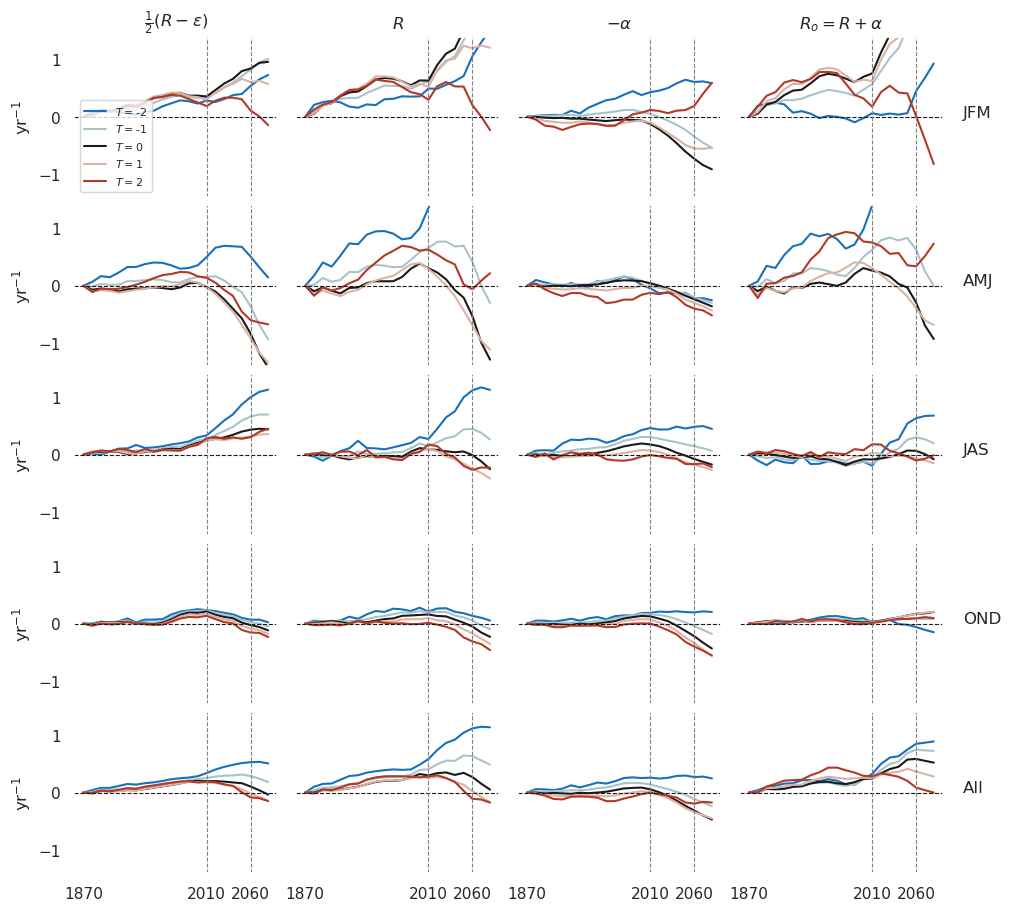

In [142]:
fig, axs = plt.subplots(5, 4, figsize=(10, 9), layout="constrained")

for j, (months, label, amp) in enumerate(
    zip(
        [[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12], np.arange(1, 13)],
        ["JFM", "AMJ", "JAS", "OND", "All"],
        [2, 2, 1.5, 1, 1],
        # [[12,1,2], [3,4,5], [6,7,8], [9,10,11], np.arange(1, 13)],
        # ["DJF", "MAM", "JJA", "SON", "All"],
        # [2, 2, 1.5, 1, 1],
    )
):

    plot_p_comp(
        axs[j], p0=0.5 * (R_nl - eps), p1=R_nl, p2=-alpha["eval"], p3=Ro, months=months
    )
    axs[j, -1].text(s=label, x=1.1, y=0.5, transform=axs[j, -1].transAxes)

for axs_ in axs[:-1]:
    for ax in axs_:
        ax.set_xticks([])

axs[0, 0].set_title(r"$\frac{1}{2}\left(R-\varepsilon\right)$")
axs[0, 1].set_title(r"$R$")
axs[0, 2].set_title(r"$-\alpha$")
axs[0, 3].set_title(r"$R_o=R+\alpha$")
axs[0, 0].legend(prop=dict(size=8), loc="lower left")


# src.utils.set_lims(axs.flatten())

save(fig, "gr-over-time", do_save=False)

plt.show()

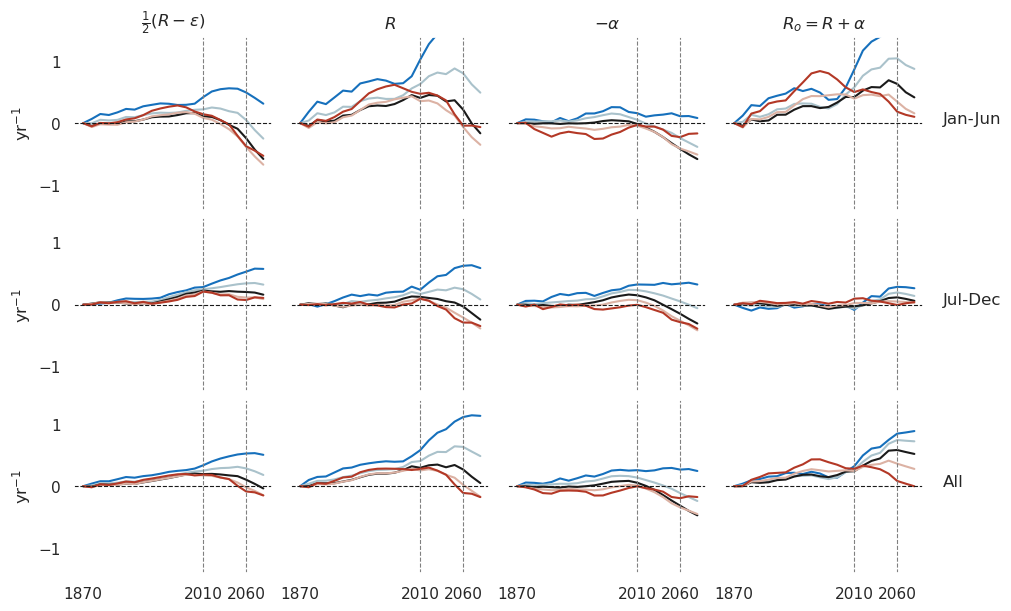

In [143]:
fig, axs = plt.subplots(3, 4, figsize=(10, 6), layout="constrained")

for j, (months, label) in enumerate(
    zip(
        [[1, 3, 4, 5, 6], [7, 8, 9, 10, 11, 12], np.arange(1, 13)],
        ["Jan-Jun", "Jul-Dec", "All"],
    )
):

    plot_p_comp(
        axs[j], p0=0.5 * (R_nl - eps), p1=R_nl, p2=-alpha["eval"], p3=Ro, months=months
    )
    axs[j, -1].text(s=label, x=1.1, y=0.5, transform=axs[j, -1].transAxes)

for axs_ in axs[:-1]:
    for ax in axs_:
        ax.set_xticks([])

axs[0, 0].set_title(r"$\frac{1}{2}\left(R-\varepsilon\right)$")
axs[0, 1].set_title(r"$R$")
axs[0, 2].set_title(r"$-\alpha$")
axs[0, 3].set_title(r"$R_o=R+\alpha$")


# src.utils.set_lims(axs.flatten())

plt.show()

#### Plot in a slightly different way

In [144]:
# fits_Ro = fits[["Lac","NROT_Lac"]] - fits_fixed_Ro[["Lac","NROT_Lac"]]
fits_Ro_ = fits[["Lac", "NROT_Lac"]] + fits_alpha[["Lac", "NROT_Lac"]]

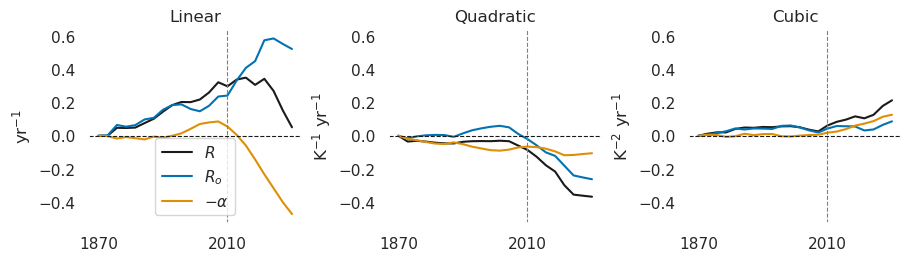

In [145]:
yr = fits.year
sel = lambda x: x[["Lac", "NROT_Lac"]].mean("cycle")
delta = lambda x: x - x.isel(year=0)
sel2 = lambda x: delta(sel(x))

## funcs to select params
sel_sym = lambda x: x["Lac"].isel(rankx=0, ranky=0)
sel_asym = lambda x: x["NROT_Lac"].isel(nro_form=0)
sel_cub = lambda x: x["NROT_Lac"].isel(nro_form=2)


fig, axs = plt.subplots(1, 3, figsize=(9, 2.5), layout="constrained")

for ax, sel_fn in zip(axs, [sel_sym, sel_asym, sel_cub]):

    ## get func to select all data
    sel_ = lambda x: sel_fn(sel2(x))

    ## plot total
    ax.plot(yr, sel_(fits), c="k", label="$R$")

    ##
    for fits_, l in zip(
        [fits_Ro_, -fits_alpha[["Lac", "NROT_Lac"]]], [r"$R_o$", r"$-\alpha$"]
    ):
        ax.plot(yr, sel_(fits_), label=l)

for ax in axs:
    ax_kwargs = dict(ls="--", c="k", lw=0.8)
    ax.axhline(0, **ax_kwargs)

src.utils.add_vticks(axs, xticks=[1870, 2010], xlines=[2010])
# axs[1].set_yticks([])

src.utils.set_lims(axs)
axs[0].set_ylabel(r"yr$^{-1}$")
axs[1].set_ylabel(r"K$^{-1}$ yr$^{-1}$")
axs[2].set_ylabel(r"K$^{-2}$ yr$^{-1}$")
axs[0].legend()
axs[0].set_title("Linear")
axs[1].set_title("Quadratic")
axs[2].set_title("Cubic")

plt.show()

### Ablation tests

#### Noise vs. nonlinearity

In [146]:
def fix_R0(params, **kwargs):
    """Fix R parameter"""

    ## fix T (linear R)
    pparams = src.utils.get_perturbed_multi(params=params, idxs=[(0, 0)], **kwargs)

    return pparams


def fix_R(params, **kwargs):
    """Fix R parameter"""

    ## fix T (linear R)
    pparams0 = src.utils.get_perturbed_multi(params=params, idxs=[(0, 0)], **kwargs)

    ## fix T2
    pparams1 = get_perturbed_NRO(nro_form_idx=0, params=pparams0, nro_type="NROT_Lac")

    ## fix T3
    pparams = get_perturbed_NRO(nro_form_idx=2, params=pparams1, nro_type="NROT_Lac")

    return pparams


def fix_F1(params, **kwargs):
    """Fix F1 parameter"""

    ## fix linear param (depependence on H)
    pparams0 = src.utils.get_perturbed_multi(params=params, idxs=[(0, 1)], **kwargs)

    ## fix dependence on H2
    pparams1 = get_perturbed_NRO(params=pparams0, nro_form_idx=-1, nro_type="NROT_Lac")

    ## fix dependence on T, H
    pparams = get_perturbed_NRO(params=pparams1, nro_form_idx=1, nro_type="NROT_Lac")

    return pparams


def fix_F2(params, **kwargs):
    """Fix F1 parameter"""

    ## fix linear param (depependence on H)
    pparams0 = src.utils.get_perturbed_multi(params=params, idxs=[(1, 0)], **kwargs)

    ## fix dependence on T2
    pparams = get_perturbed_NRO(params=pparams0, nro_form_idx=0, nro_type="NROH_Lac")

    return pparams


def fix_BJ(params, **kwargs):
    """fix R and epsilon"""

    ## get fixed R
    pparams_fixed_R = fix_R(params, **kwargs)

    ## fix epsilon
    pparams = src.utils.get_perturbed_multi(
        params=pparams_fixed_R, idxs=[(1, 1)], **kwargs
    )

    return pparams


def fix_wyrtki(params, **kwargs):
    """fix F1 and F2"""

    ## fix F1
    pparams_fixed_F1 = fix_F1(params, **kwargs)

    ## fix F2
    pparams = fix_F2(params=params_fixed_F1, **kwargs)

    return pparams


def fix_ddt_T(params, **kwargs):
    """fix R and F1"""

    ## get fixed R
    pparams_fixed_R = fix_R(params, **kwargs)

    ## fix F1
    pparams = fix_F1(params=pparams_fixed_R, **kwargs)

    return pparams


def fix_ddt_h(params, **kwargs):
    """fix epsilon and F2"""

    ## get fixed R
    pparams_fixed_F2 = fix_F2(params, **kwargs)

    ## fix F1
    pparams = fix_eps(params=pparams_fixed_F2, **kwargs)

    return pparams


def fix_eps(params, **kwargs):
    """fix epsilon"""
    pparams = src.utils.get_perturbed_multi(params=params, idxs=[(1, 1)], **kwargs)

    return pparams


def fix_cycle(params, pparams, cycle_idxs):
    """only keep perturbation for part of seasonal cycle"""

    ## these are param names to modify
    pnames = [
        "Lac",
        "NLb_Lac",
        "NLc_Lac",
        "NROT_Lac",
        "NROH_Lac",
        "xi_stdac",
        "xi_std",
        "xi_cov",
        "xi_covac",
    ]

    ## get difference in params
    dparams = fits[pnames] - pparams[pnames]

    ## get months to return to baseline values (difference b/n sets)
    idxs_to_zero = set(np.arange(12)) - set(cycle_idxs)

    ## convert from set to array
    idxs_to_zero = np.array(list(idxs_to_zero))

    ## now remove param perturbations from these indices
    dparams_updated = xr.merge(
        [
            dparams.isel(cycle=cycle_idxs).drop_vars("xi_cov"),
            xr.zeros_like(dparams.isel(cycle=idxs_to_zero)),
        ]
    )

    ## get updated param perturbations
    ## apply updated perturbation to original parameter set
    pparams_updated = copy.deepcopy(pparams)
    pparams_updated[pnames] = fits[pnames] - dparams_updated[pnames]

    return pparams_updated

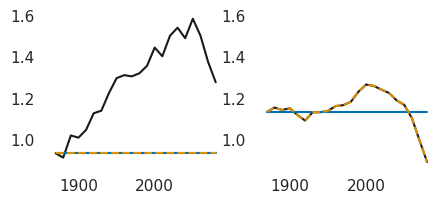

In [147]:
fits_R = fix_R(fits)
fits_R0 = fix_cycle(params=fits, pparams=fits_R, cycle_idxs=np.arange(6))

sel = lambda x: x["Lac"].isel(rankx=0, ranky=0).mean("cycle")

fig, axs = plt.subplots(1, 2, figsize=(5, 2))

for ax, cyc_idx in zip(axs, [np.arange(0, 6), np.arange(6, 12)]):

    ax.plot(fits.year, sel(fits.isel(cycle=cyc_idx)), c="k")
    ax.plot(fits.year, sel(fits_R.isel(cycle=cyc_idx)))
    ax.plot(fits.year, sel(fits_R0.isel(cycle=cyc_idx)), ls="--")

src.utils.set_lims(axs)
plt.show()

In [148]:
## should we fix the given parameter? or all others?
FIX_OTHERS = False
FIX_NOISE = False

## shared args
pparam_kwargs = dict(params=fits, fix_others=FIX_OTHERS, fix_noise=FIX_NOISE)

## get fixed params
fits_fixed_cubic = get_perturbed_NRO(nro_form_idx=2, params=fits, nro_type="NROT_Lac")
fits_fixed_quad = get_perturbed_NRO(nro_form_idx=0, params=fits, nro_type="NROT_Lac")
fits_fixed_R0 = fix_R0(**pparam_kwargs)
fits_fixed_R = fix_R(**pparam_kwargs)
fits_fixed_ddt_h = fix_ddt_h(**pparam_kwargs)
fits_fixed_ddt_T = fix_ddt_T(**pparam_kwargs)
fits_fixed_noise = src.utils.get_perturbed_noise(fits, fix_others=FIX_OTHERS)
fits_fixed_Ro_F1 = fix_F1(params=fits_fixed_Ro)

## fix ocean terms
fits_fixed_cubic = get_perturbed_NRO(nro_form_idx=2, params=fits, nro_type="NROT_Lac")
fits_fixed_quad = get_perturbed_NRO(nro_form_idx=0, params=fits, nro_type="NROT_Lac")
fits_fixed_R0 = fix_R0(**pparam_kwargs)

## shared args (fix cycle)
# cyc_kwargs = dict(params=fits, pparams=fits_fixed_ddt_T)
# cyc_kwargs = dict(params=fits, pparams=fits_fixed_R)
cyc_kwargs = dict(params=fits, pparams=fits_fixed_Ro_F1)
# cyc_kwargs = dict(params=fits, pparams=fits_fixed_noise)

## specify params for experiments
param_set_dict = {
    "Control": fits,
    "Fix noise": fits_fixed_noise,
    # r"Fix $R$, $F_1$": fits_fixed_ddt_T,
    r"Fix $R_o$, $F_1$": fits_fixed_Ro_F1,
    # r"Fix $R$": fits_fixed_R,
    # r"Fix lin.": fits_fixed_R0,
    # r"Fix quad": fits_fixed_quad,
    # r"Fix cubic": fits_fixed_cubic,
    # r"Fix cubic": fits_fixed_cubic,
    r"Fix $\alpha$": fits_fixed_alpha,
    r"Fix $F_2$, $\varepsilon$": fits_fixed_ddt_h,
    # r"Fix $F_1$": fix_F1(**pparam_kwargs),
    # r"Fix $R$, $F_1$ (JFM)": fix_cycle(cycle_idxs=np.arange(0, 3), **cyc_kwargs),
    # r"Fix $R$, $F_1$ (AMJ)": fix_cycle(cycle_idxs=np.arange(3, 6), **cyc_kwargs),
    # r"Fix $R$, $F_1$ (JAS)": fix_cycle(cycle_idxs=np.arange(6, 9), **cyc_kwargs),
    # r"Fix $R$, $F_1$ (OND)": fix_cycle(cycle_idxs=np.arange(9, 12), **cyc_kwargs),
    # r"Fix $R$, $F_1$ (Jul-Dec)": fix_cycle(
    #     params=fits,
    #     pparams=fix_ddt_T(**pparam_kwargs),
    #     cycle_idxs=np.arange(6, 12),
    # ),
    # r"Fix $\varepsilon$": fix_eps(**pparam_kwargs),
    # r"Fix BJ": fits_fixed_BJ,
    # r"Fix $R_0$": fits_fixed_R0,
    # r"Fix Wyrtki": fits_fixed_wyrtki,
    # r"Fix $b$": get_perturbed_NRO(nro_form_idx=0, params=fits, nro_type="NROT_Lac"),
    # r"Fix $R_o$": fits_fixed_Ro,
    # r"Fix $\alpha$": fits_fixed_alpha,
    # r"Fix $\varepsilon$": fits_fixed_eps,
    # r"Fix Jan-Jun": fits_cyc0,
    # r"Fix Jul-Dec": fits_cyc1,
    # r"Fixed $R_3$": src.utils.get_perturbed_multi(idxs=[(2, 2)], **pparam_kwargs),
    # r"Fix $L_o$": fits_fixed_Lo,
}

# ## get list of param sets and labels
param_sets = list(param_set_dict.values())
labels = list(param_set_dict.keys())

In [149]:
def plot_param_set(ax, params, model):
    """plot parameter set over time for given experiment"""

    ## get named named params (nnual mean)
    params_ = params.mean("cycle")

    ## plot core params
    for p in ["R", "epsilon", "F1", "F2", "bT_1", "cT_1", "bH_1"]:
        plot = ax.plot(params_.year, params_[p], label=p)
        ax.axhline(params_[p].isel(year=0), ls="--", c=plot[0].get_color(), lw=0.5)

    ## plot noise
    for p, c in zip(["xi_T", "xi_h"], ["gray", "lightgray"]):
        ax.plot(params_.year, params_[p], label=p, c=c)
        ax.axhline(params_[p].isel(year=0), ls="--", c=c, lw=0.5)

    ## format ax
    ax.set_xticks([])
    ax.legend(loc=(1.3, 0.1), prop=dict(size=6))

    return

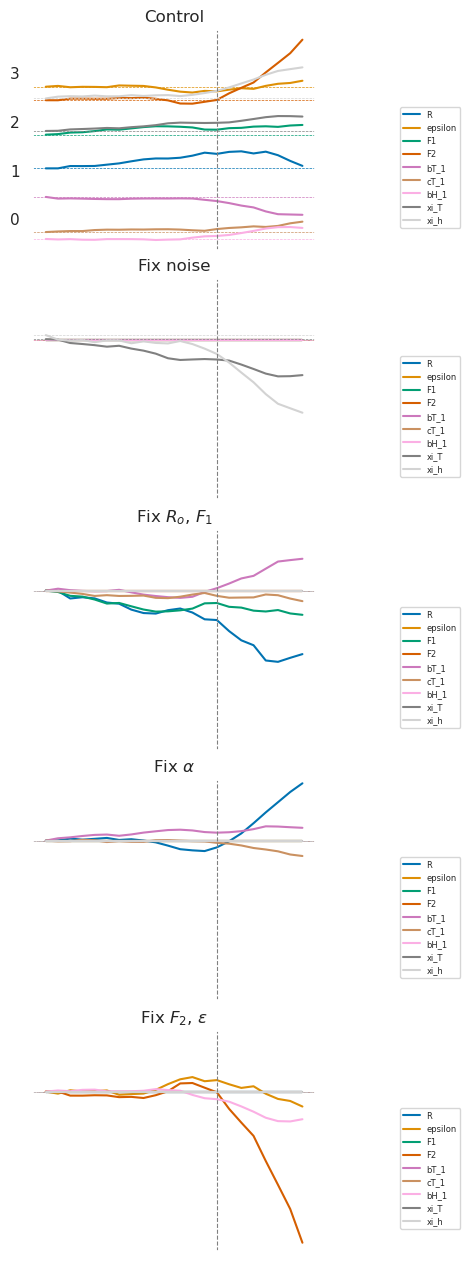

In [150]:
fig, axs = plt.subplots(
    len(labels), 1, figsize=(4.5, 2.5 * len(labels)), layout="constrained"
)

## plot control
params0 = MODEL.get_RO_parameters(param_sets[0])
plot_param_set(axs[0], params0, model=MODEL)
axs[0].set_title(labels[0])

## plot diff from control
for ax, param_set, label in zip(axs[1:], param_sets[1:], labels[1:]):

    params_ = MODEL.get_RO_parameters(param_set)

    plot_param_set(ax, params_ - params0, model=MODEL)
    ax.set_title(label)

## formatting
src.utils.set_lims(axs[1:])
for ax in axs[1:]:
    ax.set_yticks([])


## legend
# axs[-1].legend(loc=(1.3, 0.1), prop=dict(size=8))
src.utils.add_vticks(axs, xticks=[], xlines=[2010])

plt.show()

In [151]:
params0 = MODEL.get_RO_parameters(param_sets[0]).isel(year=0)
delta = lambda x: (x - params0).mean("cycle")
delta0 = delta(MODEL.get_RO_parameters(param_sets[0]))
deltan = delta(MODEL.get_RO_parameters(param_sets[1]))
delta01 = delta(MODEL.get_RO_parameters(param_sets[-2]))
delta02 = delta(MODEL.get_RO_parameters(param_sets[-1]))

Get simulations over time

In [152]:
exp_kwargs = dict(**simulation_kwargs, model=MODEL)
sims_exp = [sims] + [get_sims_over_time(params=p, **exp_kwargs) for p in param_sets[1:]]

 77%|███████▋  | 17/22 [00:13<00:04,  1.20it/s]/glade/u/home/kcarr/RO-change-over-time/src/XRO.py:1239: RuntimeWarning: overflow encountered in square
  b[:, None] * X**2
/glade/u/home/kcarr/RO-change-over-time/src/XRO.py:1239: RuntimeWarning: invalid value encountered in multiply
  b[:, None] * X**2
/glade/u/home/kcarr/RO-change-over-time/src/XRO.py:1240: RuntimeWarning: overflow encountered in power
  + c[:, None] * X**3
/glade/u/home/kcarr/RO-change-over-time/src/XRO.py:1240: RuntimeWarning: invalid value encountered in multiply
  + c[:, None] * X**3
/glade/u/home/kcarr/RO-change-over-time/src/XRO.py:1628: RuntimeWarning: overflow encountered in multiply
  RO_T2 = X[0,] * X[0,]
/glade/u/home/kcarr/RO-change-over-time/src/XRO.py:1630: RuntimeWarning: overflow encountered in multiply
  RO_T3 = X[0,] * X[0,] * X[0,]
/glade/u/home/kcarr/RO-change-over-time/src/XRO.py:1631: RuntimeWarning: overflow encountered in multiply
  RO_T2H = X[0,] * X[0,] * X[1,]
/glade/u/home/kcarr/RO-change-ove

#### Func to compute warm/cold variance

In [153]:
import pandas as pd


def var_by_quant(x):
    """compute variance by quantiles"""

    ## get bounds
    bounds = x.quantile(dim=["member", "time"], q=[0.25, 0.75]).rename(
        {"quantile": "q"}
    )

    ## find samples in each class
    in_class0 = x < bounds.isel(q=0)  ## extreme La Niña
    in_class1 = (bounds.isel(q=0) <= x) & (x <= bounds.isel(q=1))  ## neutral
    in_class2 = bounds.isel(q=1) < x  ## extreme El Niño

    ## put in single dataarray
    in_class = xr.concat(
        [in_class0, in_class1, in_class2],
        dim=pd.Index(np.arange(3), name="intensity"),
        coords="minimal",
        compat="override",
    )

    ## compute variance from each
    N = (~np.isnan(x)).sum(["member", "time"])
    x_var = 1 / N * (x.where(in_class) ** 2).sum(["time", "member"])

    return x_var

#### Compute stats over time

In [154]:
## stat
get_q = lambda x: x.quantile(q=[0.1, 0.5, 0.9], dim="member").rename({"quantile": "q"})

## funcs to get stats over time
get_fn_ot = lambda exps, fn: [get_q(exp.groupby("time.season").map(fn)) for exp in exps]
get_fn_ot2 = lambda exps, fn: [exp.groupby("time.season").map(fn) for exp in exps]

## compute
sigma_exp = get_fn_ot(sims_exp, lambda x: x.std("time"))
quantiles_exp = get_fn_ot2(sims_exp, get_stats)
var_exp = get_fn_ot2(sims_exp, var_by_quant)

/glade/u/home/kcarr/RO-change-over-time/envs/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1872: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)
/glade/u/home/kcarr/RO-change-over-time/envs/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1872: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)
/glade/u/home/kcarr/RO-change-over-time/envs/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1872: RuntimeWarning: overflow encountered in multiply
  sqr = np.multiply(arr, arr, out=arr, where=where)
/glade/u/home/kcarr/RO-change-over-time/envs/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/glade/u/home/kcarr/RO-change-over-time/envs/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1872: RuntimeWarning: overflow encountered i

### Plot results

In [155]:
def format_row(axs, y0, season):
    """format row of plot in comparison"""

    ## label
    axs[0].set_yticks([np.round(sigma0, 1), np.round(sigma0 + 0.5, 1)])
    for ax in axs[1:]:
        ax.set_ylabel(None)
    axs[-1].set_ylabel(season)
    axs[-1].yaxis.set_label_position("right")
    for ax in axs:
        ax.axhline(y0, c="gray", lw=1, ls="--")
        ax.set_ylim([y0 - 0.3, y0 + 0.7])

    return


def format_subplots(axs, labels):
    """format all subplots"""
    for ax in axs[:-1].flatten():
        ax.set_xticks([])
        ax.set_xlabel(None)

    for ax in axs[:, 1:].flatten():
        ax.set_yticks([])

    for j in range(axs.shape[1]):
        axs[0, j].set_title(labels[j])

    return


def plot_stats_comp(ax, list_of_stats, labels, colors=None, n=varnames[0]):
    """plot comparison of variance over time"""

    if colors is None:
        colors = sns.color_palette()[: len(list_of_stats)]

    for stats, label, c in zip(list_of_stats, labels, colors):

        ## plot median
        mplot = ax.plot(stats.year, stats[n].sel(q=0.5), lw=2.5, label=label, c=c)

        ## plot lower/upper quantiles
        kwargs = dict(c=mplot[0].get_color(), lw=0.8)
        for q in stats.q:
            if q != 0.5:
                ax.plot(stats.year, stats[n].sel(q=q), **kwargs)

    ## label and set plotting specs
    ax.set_xlabel("Year")
    ax.set_ylabel(r"$\sigma_T$ ($^{\circ}$C)")
    ax.set_ylim([0.3, 1.7])
    ax.set_xticks([1870, 2010, 2080])
    ax.set_yticks([0.6, 1.2])

    return

#### Variance

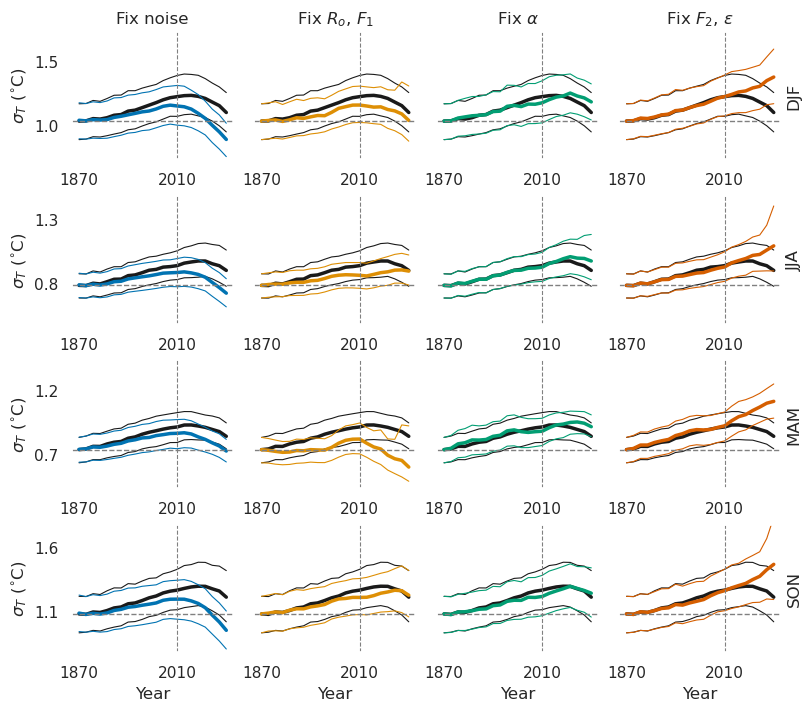

In [156]:
## specify which variable to plot
PLOT_VAR = varnames[0]

## plot results
n = len(sigma_exp) - 1
fig, axs = plt.subplots(4, n, figsize=(n * 2, 7), layout="constrained")

for i, s in enumerate(sigma_exp[0].season.values):

    ## loop thru experiments
    for j in np.arange(len(sigma_exp) - 1):
        plot_stats_comp(
            axs[i, j],
            [sigma_exp[0].sel(season=s), sigma_exp[j + 1].sel(season=s)],
            labels=[labels[0], labels[j + 1]],
            colors=["k", sns.color_palette()[j]],
            n=PLOT_VAR,
        )

    ## get baseline value
    sigma0 = sigma_exp[0].sel(season=s)[PLOT_VAR].isel(q=1, year=0).values.item()

    ## format
    format_row(axs=axs[i], y0=sigma0, season=s)

## format all subplots
format_subplots(axs, labels=labels[1:])
src.utils.add_vticks(axs.flatten(), xticks=[1870, 2010], xlines=[2010])

# save(fig, fname="ro-experiments")

plt.show()

#### Extremes

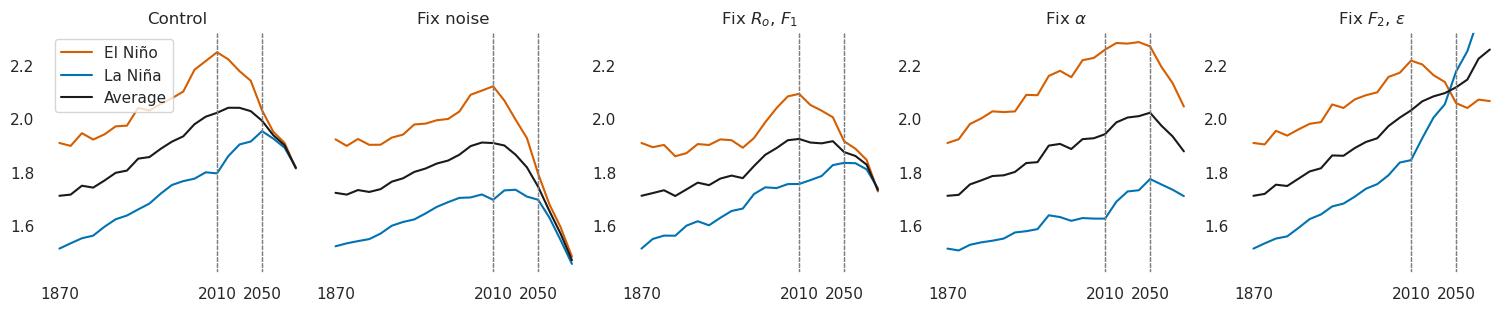

In [157]:
## SPECIFY SEASON
SEASON = "DJF"

fig, axs = plt.subplots(
    1, len(quantiles_exp), figsize=(3 * len(quantiles_exp), 3), layout="constrained"
)
for ax, stats_, title in zip(axs, quantiles_exp, labels):
    q = stats_.sel(season=SEASON)["q"].sel(v=PLOT_VAR)

    ax.plot(stats_.year, q.sel(quantile=0.95), c="r", label="El Niño")
    ax.plot(stats_.year, -q.sel(quantile=0.05), c="b", label="La Niña")
    ax.plot(
        stats_.year,
        0.5 * (q.sel(quantile=0.95) - q.sel(quantile=0.05)),
        label="Average",
        c="k",
    )

    ax_kwargs = dict(ls="--", c="gray", lw=0.8)
    add_vticks(axs, xticks=[1870, 2010, 2050], xlines=[2010, 2050])
    ax.set_title(title)

src.utils.set_lims(axs[:-1])
for ax in axs[1:]:
    axs[1].set_yticks([])
axs[0].legend()
axs[-1].set_ylim(axs[0].get_ylim())

## save to file
save(fig, fname="RO-experiments", do_save=False)

plt.show()

#### Same, but plot effect

Compute effect

In [158]:
## for quantiles
ctrl_ = quantiles_exp[0]
quantiles_eff = [ctrl_ - q for q in quantiles_exp]

## for variance
ctrl_var = var_exp[0]
var_eff = [ctrl_var - q for q in var_exp]

Plot effect

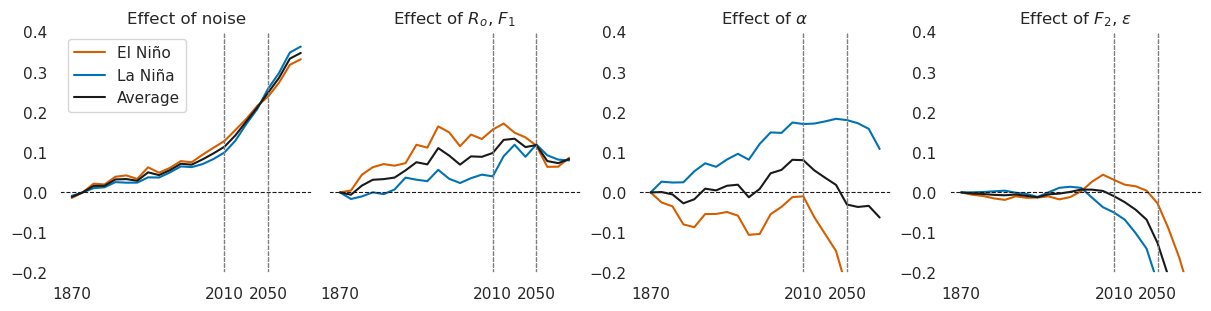

In [159]:
## specify seaons
SEASON = "DJF"

## number of figures in panel
n = len(quantiles_exp) - 1

## get control
ctrl = ctrl_.sel(season=SEASON)["q"].sel(v=PLOT_VAR)

## make plot
fig, axs = plt.subplots(1, n, figsize=(3 * (n), 3), layout="constrained")
for ax, stats_, title in zip(axs, quantiles_eff[1:], labels[1:]):
    q = stats_.sel(season=SEASON)["q"].sel(v=PLOT_VAR)

    ax.plot(
        stats_.year,
        q.sel(quantile=0.95),
        c="r",
        label="El Niño",
    )
    ax.plot(
        stats_.year,
        -q.sel(quantile=0.05),
        c="b",
        label="La Niña",
    )
    ax.plot(
        stats_.year,
        0.5 * (q.sel(quantile=0.95) - q.sel(quantile=0.05)),
        label="Average",
        c="k",
    )

    ax_kwargs = dict(ls="--", c="gray", lw=0.8)
    add_vticks(axs, xticks=[1870, 2010, 2050], xlines=[2010, 2050])
    ax.axhline(0, ls="--", c="k", lw=0.8)
    ax.set_title(f"Effect of {title[4:]}")
    ax.set_ylim([-0.2, 0.4])

src.utils.set_lims(axs)
# src.utils.set_lims(axs[4:])
for ax in axs[1:]:
    axs[1].set_yticks([])

axs[-1].set_ylim(axs[0].get_ylim())
axs[0].legend()

plt.show()

#### Check linearity

$R$ and noise

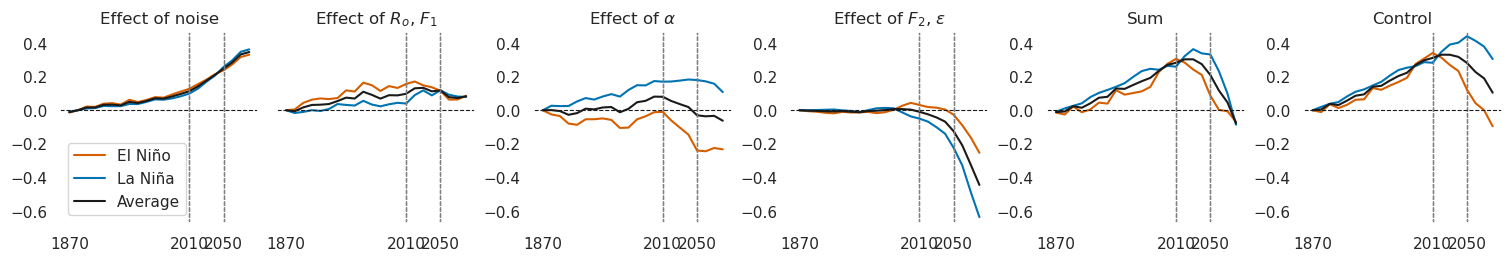

In [161]:
SEASON = "DJF"

# for idxs in [[1,2,-1], [1,3,4]]:
# for idxs in [[1,2,4], [1,5,6, 4]]:
for idxs in [[1, 2, 3, 4]]:
    plot_vars = [quantiles_eff[i] for i in idxs]
    plot_labs = [labels[i] for i in idxs]

    ## get control effect
    ctrl_eff = quantiles_exp[0] - quantiles_exp[0].isel(year=0)

    ## get sum
    sum_ = xr.zeros_like(quantiles_eff[0])
    for i in idxs:
        sum_ += quantiles_eff[i]

    n = len(idxs) + 2

    fig, axs = plt.subplots(1, n, figsize=(2.5 * n, 2.5), layout="constrained")
    for ax, stats_, title in zip(
        axs, plot_vars + [sum_] + [ctrl_eff], plot_labs + ["sum"] + ["Control"]
    ):
        q = stats_.sel(season=SEASON)["q"].sel(v=PLOT_VAR)

        ax.plot(
            stats_.year,
            q.sel(quantile=0.95),
            c="r",
            label="El Niño",
        )
        ax.plot(
            stats_.year,
            -q.sel(quantile=0.05),
            c="b",
            label="La Niña",
        )
        ax.plot(
            stats_.year,
            0.5 * (q.sel(quantile=0.95) - q.sel(quantile=0.05)),
            label="Average",
            c="k",
        )

        ax_kwargs = dict(ls="--", c="gray", lw=0.8)
        add_vticks(axs, xticks=[1870, 2010, 2050], xlines=[2010, 2050])
        ax.axhline(0, ls="--", c="k", lw=0.8)
        ax.set_title(f"Effect of {title[4:]}")
        # ax.set_ylim([-.2,.4])

    axs[-2].set_title("Sum")
    axs[-1].set_title("Control")
    src.utils.set_lims(axs)
    for ax in axs[1:]:
        axs[1].set_yticks([])
    axs[0].legend()

    plt.show()

seasonal

In [ ]:
## specify season
SEASON = "DJF"

## specify which experiments to plot
# idxs = [3, 4, 5, 6, 2]
# idxs = [3, 4, 2]
idxs = [3, 4, 5, 2]
plot_vars = [quantiles_eff[i] for i in idxs]
plot_labs = [labels[i] for i in idxs]

## get control effect
ctrl_eff = quantiles_exp[0] - quantiles_exp[0].isel(year=0)

## get sum
sum_ = xr.zeros_like(quantiles_eff[0])
for i in idxs[:-1]:
    sum_ += quantiles_eff[i]

fig, axs = plt.subplots(
    1, len(idxs) + 1, figsize=(2.5 * (len(idxs) + 1), 2.5), layout="constrained"
)
for ax, stats_, title in zip(axs, plot_vars + [sum_], plot_labs + ["sum"]):
    q = stats_.sel(season=SEASON)["q"].sel(v=PLOT_VAR)

    ax.plot(
        stats_.year,
        q.sel(quantile=0.95),
        c="r",
        label="El Niño",
    )

    ax.plot(
        stats_.year,
        -q.sel(quantile=0.05),
        c="b",
        label="La Niña",
    )
    ax.plot(
        stats_.year,
        0.5 * (q.sel(quantile=0.95) - q.sel(quantile=0.05)),
        label="Average",
        c="k",
    )

    ax_kwargs = dict(ls="--", c="gray", lw=0.8)
    add_vticks(axs, xticks=[1870, 2010, 2050], xlines=[2010, 2050])
    ax.axhline(0, ls="--", c="k", lw=0.8)
    # ax.axhline(0.05, ls="--", c="k", lw=0.8)
    ax.set_title(f"Effect of {title[4:]}")

# axs[-2].set_title("Sum")
axs[-2].set_title(r"Effect of $R$ (ctrl)")
axs[-1].set_title("Sum")
src.utils.set_lims(axs)
for ax in axs[1:]:
    axs[1].set_yticks([])
axs[0].legend()

plt.show()

##### $R_o$ and $\alpha$

In [ ]:
## specify season
SEASON = "DJF"

## specify which experiments to plot
idxs = [5, 6, 2]
plot_vars = [quantiles_eff[i] for i in idxs]
plot_labs = [labels[i] for i in idxs]

## get control effect
ctrl_eff = quantiles_exp[0] - quantiles_exp[0].isel(year=0)

## get sum
sum_ = xr.zeros_like(quantiles_eff[0])
for i in idxs[:-1]:
    sum_ += quantiles_eff[i]

fig, axs = plt.subplots(1, 4, figsize=(2.5 * 4, 2.5), layout="constrained")
for ax, stats_, title in zip(axs, plot_vars + [sum_], plot_labs + ["sum"]):
    q = stats_.sel(season=SEASON)["q"].sel(v=PLOT_VAR)

    ax.plot(
        stats_.year,
        q.sel(quantile=0.95),
        c="r",
        label="El Niño",
    )

    ax.plot(
        stats_.year,
        -q.sel(quantile=0.05),
        c="b",
        label="La Niña",
    )
    ax.plot(
        stats_.year,
        0.5 * (q.sel(quantile=0.95) - q.sel(quantile=0.05)),
        label="Average",
        c="k",
    )

    ax_kwargs = dict(ls="--", c="gray", lw=0.8)
    add_vticks(axs, xticks=[1870, 2010, 2050], xlines=[2010, 2050])
    ax.axhline(0, ls="--", c="k", lw=0.8)
    ax.set_title(f"Effect of {title[4:]}")

# axs[-2].set_title("Sum")
axs[-2].set_title(r"Effect of $R$ (ctrl)")
axs[-1].set_title("Sum")
src.utils.set_lims(axs)
for ax in axs[1:]:
    axs[1].set_yticks([])
axs[0].legend()

plt.show()

#### seasonality

In [ ]:
## specify season
SEASON = "DJF"

## specify which experiments to plot
idxs = [1, 7, 8]
plot_vars = [quantiles_eff[i] for i in idxs]
plot_labs = [labels[i] for i in idxs]

## get control effect
ctrl_eff = quantiles_exp[0] - quantiles_exp[0].isel(year=0)

## get sum
sum_ = xr.zeros_like(quantiles_eff[0])
for i in idxs:
    sum_ += quantiles_eff[i]

fig, axs = plt.subplots(1, 5, figsize=(2.5 * 5, 2.5), layout="constrained")
for ax, stats_, title in zip(
    axs, plot_vars + [sum_] + [ctrl_eff], plot_labs + ["sum"] + ["Control"]
):
    q = stats_.sel(season=SEASON)["q"].sel(v=PLOT_VAR)

    ax.plot(
        stats_.year,
        q.sel(quantile=0.95),
        c="r",
        label="El Niño",
    )
    ax.plot(
        stats_.year,
        -q.sel(quantile=0.05),
        c="b",
        label="La Niña",
    )
    ax.plot(
        stats_.year,
        0.5 * (q.sel(quantile=0.95) - q.sel(quantile=0.05)),
        label="Average",
        c="k",
    )

    ax_kwargs = dict(ls="--", c="gray", lw=0.8)
    add_vticks(axs, xticks=[1870, 2010, 2050], xlines=[2010, 2050])
    ax.axhline(0, ls="--", c="k", lw=0.8)
    ax.set_title(f"Effect of {title[4:]}")

axs[-2].set_title("Sum")
axs[-1].set_title("Control")
src.utils.set_lims(axs)
for ax in axs[1:]:
    axs[1].set_yticks([])
axs[0].legend()

plt.show()

Fix $\alpha$ and $R_o$

In [ ]:
## get operator variable names
op_names = ["Lac", "NROT_Lac"]

## compute perturbed (fix alpha)
fits_fixed_alpha = copy.deepcopy(fits_Ro)
fits_fixed_alpha[op_names] = fits_Ro[op_names] - fits_alpha[op_names].isel(year=0)

## Same, but fix Ro
fits_fixed_Ro = copy.deepcopy(fits_Ro)
fits_fixed_Ro[op_names] = fits_Ro[op_names].isel(year=0) - fits_alpha[op_names]

Check it works

In [ ]:
print(
    np.allclose(
        alpha["params"].sel(param="a"),
        (fits_Ro["Lac"] - fits["Lac"]).isel(rankx=0, ranky=0),
    )
)
print(
    np.allclose(
        alpha["params"].sel(param="b"),
        (fits_Ro["NROT_Lac"] - fits["NROT_Lac"]).isel(nro_form=0),
    )
)
print(
    np.allclose(
        alpha["params"].sel(param="c"),
        (fits_Ro["NROT_Lac"] - fits["NROT_Lac"]).isel(nro_form=2),
    )
)

print(
    np.allclose(
        fits_alpha[["Lac", "NROT_Lac"]].to_dataarray(),
        (fits_Ro[["Lac", "NROT_Lac"]] - fits[["Lac", "NROT_Lac"]]).to_dataarray(),
    )
)

## Scratch: same but for variance

In [ ]:
SEASON = "DJF"

idxs = [1, 2, 4]
plot_vars = [var_eff[i] for i in idxs]
plot_labs = [labels[i] for i in idxs]

## get control effect
ctrl_eff = var_exp[0] - var_exp[0].isel(year=0)

## get sum
sum_ = xr.zeros_like(var_eff[0])
for i in idxs:
    sum_ += var_eff[i]

fig, axs = plt.subplots(1, 5, figsize=(2.5 * 5, 2.5), layout="constrained")
for ax, stats_, title in zip(
    axs, plot_vars + [sum_] + [ctrl_eff], plot_labs + ["sum"] + ["Control"]
):
    q = stats_[varnames[0]].sel(season=SEASON)

    ax.plot(
        stats_.year,
        q.isel(intensity=2),
        c="r",
        label="El Niño",
    )
    ax.plot(
        stats_.year,
        q.isel(intensity=0),
        c="b",
        label="La Niña",
    )
    ax.plot(
        stats_.year,
        0.5 * q.sum("intensity"),
        label="Average",
        c="k",
    )

    ax_kwargs = dict(ls="--", c="gray", lw=0.8)
    add_vticks(axs, xticks=[1870, 2010, 2050], xlines=[2010, 2050])
    ax.axhline(0, ls="--", c="k", lw=0.8)
    ax.set_title(f"Effect of {title[4:]}")

axs[-2].set_title("Sum")
axs[-1].set_title("Control")
src.utils.set_lims(axs)
for ax in axs[1:]:
    axs[1].set_yticks([])
axs[0].legend()

plt.show()

In [ ]:
SEASON = "DJF"

idxs = [1, 5, 6]
plot_vars = [var_eff[i] for i in idxs]
plot_labs = [labels[i] for i in idxs]

## get control effect
ctrl_eff = var_exp[0] - var_exp[0].isel(year=0)

## get sum
sum_ = xr.zeros_like(var_eff[0])
for i in idxs:
    sum_ += var_eff[i]

fig, axs = plt.subplots(1, 5, figsize=(2.5 * 5, 2.5), layout="constrained")
for ax, stats_, title in zip(
    axs, plot_vars + [sum_] + [ctrl_eff], plot_labs + ["sum"] + ["Control"]
):
    q = stats_[varnames[0]].sel(season=SEASON)

    ax.plot(
        stats_.year,
        q.isel(intensity=2),
        c="r",
        label="El Niño",
    )
    ax.plot(
        stats_.year,
        q.isel(intensity=0),
        c="b",
        label="La Niña",
    )
    ax.plot(
        stats_.year,
        0.5 * q.sum("intensity"),
        label="Average",
        c="k",
    )

    ax_kwargs = dict(ls="--", c="gray", lw=0.8)
    add_vticks(axs, xticks=[1870, 2010, 2050], xlines=[2010, 2050])
    ax.axhline(0, ls="--", c="k", lw=0.8)
    ax.set_title(f"Effect of {title[4:]}")

axs[-2].set_title("Sum")
axs[-1].set_title("Control")
for ax in [axs[1], axs[3]]:
    ax.set_ylim(axs[0].get_ylim())
src.utils.set_lims(axs)
for ax in axs[1:]:
    axs[1].set_yticks([])
axs[0].legend()

plt.show()

#### Seasonality